In [ ]:
!pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#create function to download data
def load_data(tickers, start, end):

  data = yf.download(tickers,
                     start, end,
                     auto_adjust = False)
  data.to_csv("market_data.csv")

  return data

In [ ]:
#download data for bitcoin, ethereum, XRP, S&P 500, FTSE 100, BSE SENSEX
tickers = ["BTC-USD", "ETH-USD", "XRP-USD", "^GSPC", "^FTSE", '^BSESN']
raw = load_data(tickers, '2017-12-31', '2026-01-01')
renamed_raw = raw.rename(columns={'BTC-USD': 'Bitcoin',
                                   'ETH-USD': 'Ethereum',
                                   'XRP-USD': 'XRP',
                                   '^GSPC': 'S&P 500',
                                   '^FTSE': 'FTSE 100',
                                   '^BSESN': 'BSE SENSEX'})

closing_data = renamed_raw["Close"]
closing_data

[*********************100%***********************]  6 of 6 completed


Ticker,Bitcoin,Ethereum,XRP,BSE SENSEX,FTSE 100,S&P 500
Date,,,,,,
2017-12-31,14156.400391,756.732971,2.300570,NaN,NaN,NaN
2018-01-01,13657.200195,772.640991,2.391030,33812.750000,NaN,NaN
2018-01-02,14982.099609,884.443970,2.480900,33812.261719,7648.100098,2695.810059
2018-01-03,15201.000000,962.719971,3.105370,33793.378906,7671.100098,2713.060059
2018-01-04,15599.200195,980.921997,3.196630,33969.640625,7695.899902,2723.989990
...,...,...,...,...,...,...
2025-12-27,87802.156250,2947.998291,1.872853,NaN,NaN,NaN
2025-12-28,87835.835938,2948.568115,1.864360,NaN,NaN,NaN
2025-12-29,87138.140625,2934.538330,1.847724,84695.539062,9866.500000,6905.740234


In [ ]:
# Separate markets
Markets = ["Bitcoin", "Ethereum", "XRP",
           "S&P 500", "FTSE 100", "BSE SENSEX"]

market_returns = {}

for market in Markets:
    # Keep this market's available closing prices
    prices = closing_data[market].dropna()

    # Calculate returns between consecutive available prices
    market_returns[market] = np.log(
        prices / prices.shift(1)
    ).dropna()

# Combine into a dataframe if needed
log_returns_data = pd.DataFrame(market_returns)

In [ ]:
#summary statistic table of data
summary_stats = []

for market in Markets:

    series = log_returns_data[market].dropna()

    summary_stats.append({
        "Market": market,
        "N": series.count(),
        "Mean": series.mean(),
        "SD": series.std(),
        "Min": series.min(),
        "Max": series.max(),
        "Skewness": series.skew(),
        "Kurtosis": series.kurt()
    })

summary_stats_df = pd.DataFrame(summary_stats).round(4)

summary_stats_df.to_csv("summary_stats.csv", index=False)

# **Research Question 1**

1. Investigate volatility clustering

In [ ]:
#calculate squared returns and absolute returns
squared_returns = {}
absolute_returns = {}

for market in Markets:
  squared_returns[market] = market_returns[market] ** 2
  absolute_returns[market] = np.abs(market_returns[market])

In [ ]:
#combine into dataframes
df_squared_returns = pd.DataFrame(squared_returns)
df_absolute_returns = pd.DataFrame(absolute_returns)

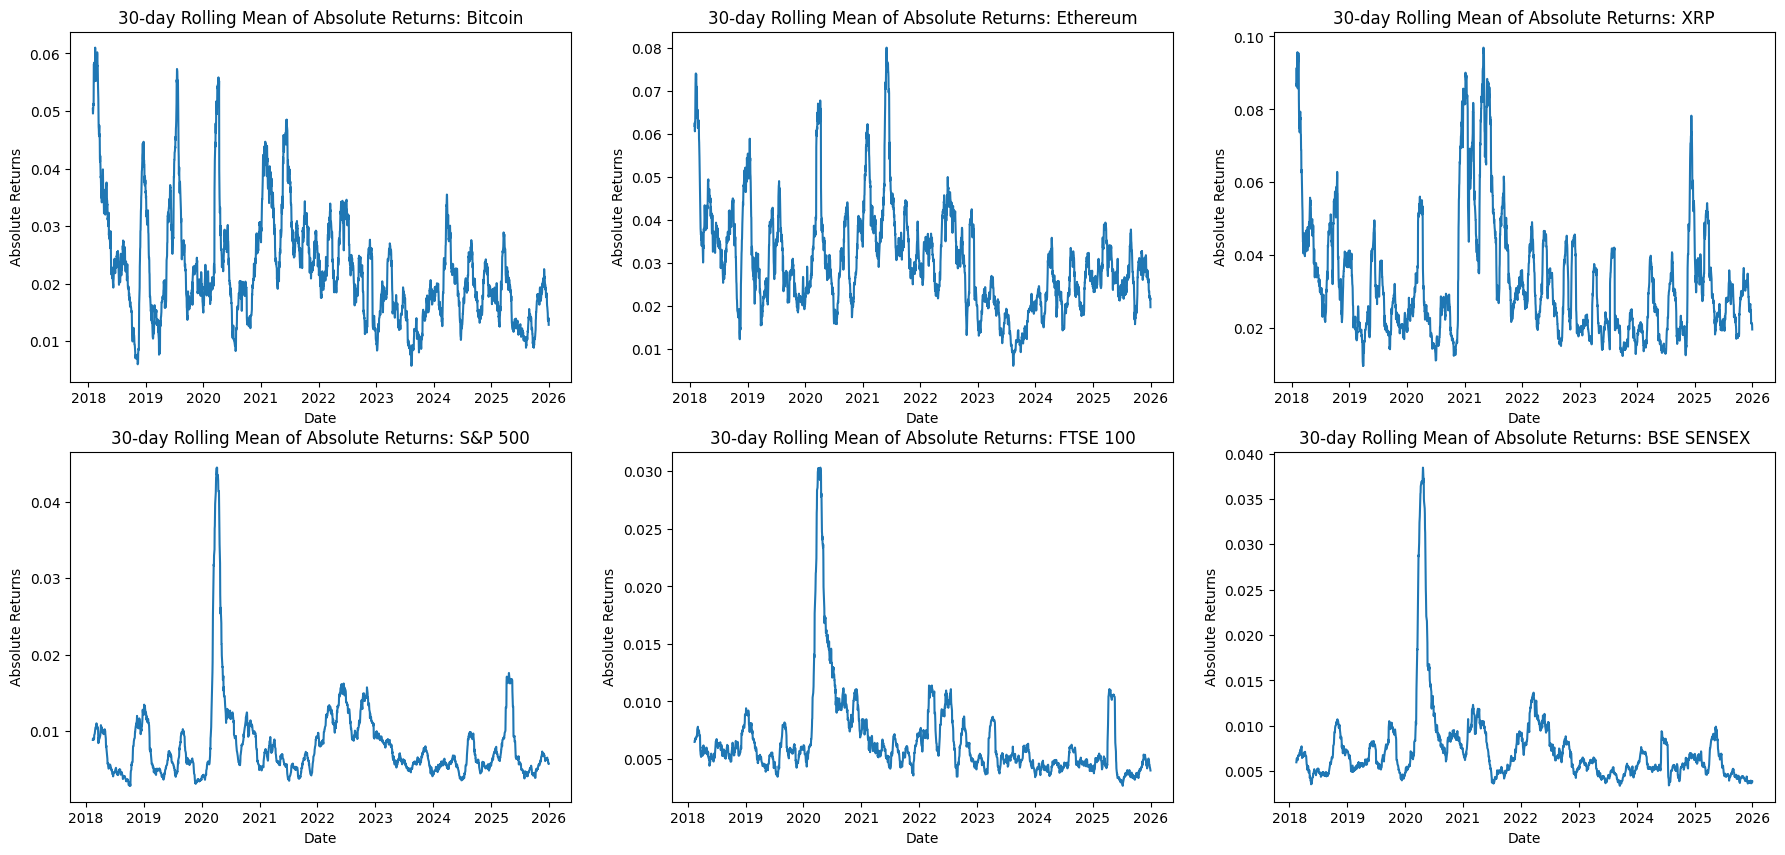

In [ ]:
#individual plot of absolute returns for each market
plt.figure(figsize=(22, 10))
plot_number = 1

for market in Markets:
  plt.subplot(2, 3, plot_number)
  plt.plot(df_absolute_returns[market].dropna().rolling(30).mean())
  plt.title(f'30-day Rolling Mean of Absolute Returns: {market}')
  plt.xlabel('Date')
  plt.ylabel('Absolute Returns')
  plot_number +=1

plt.savefig('fig1.png',
            dpi=300,
            bbox_inches = 'tight')

plt.show()

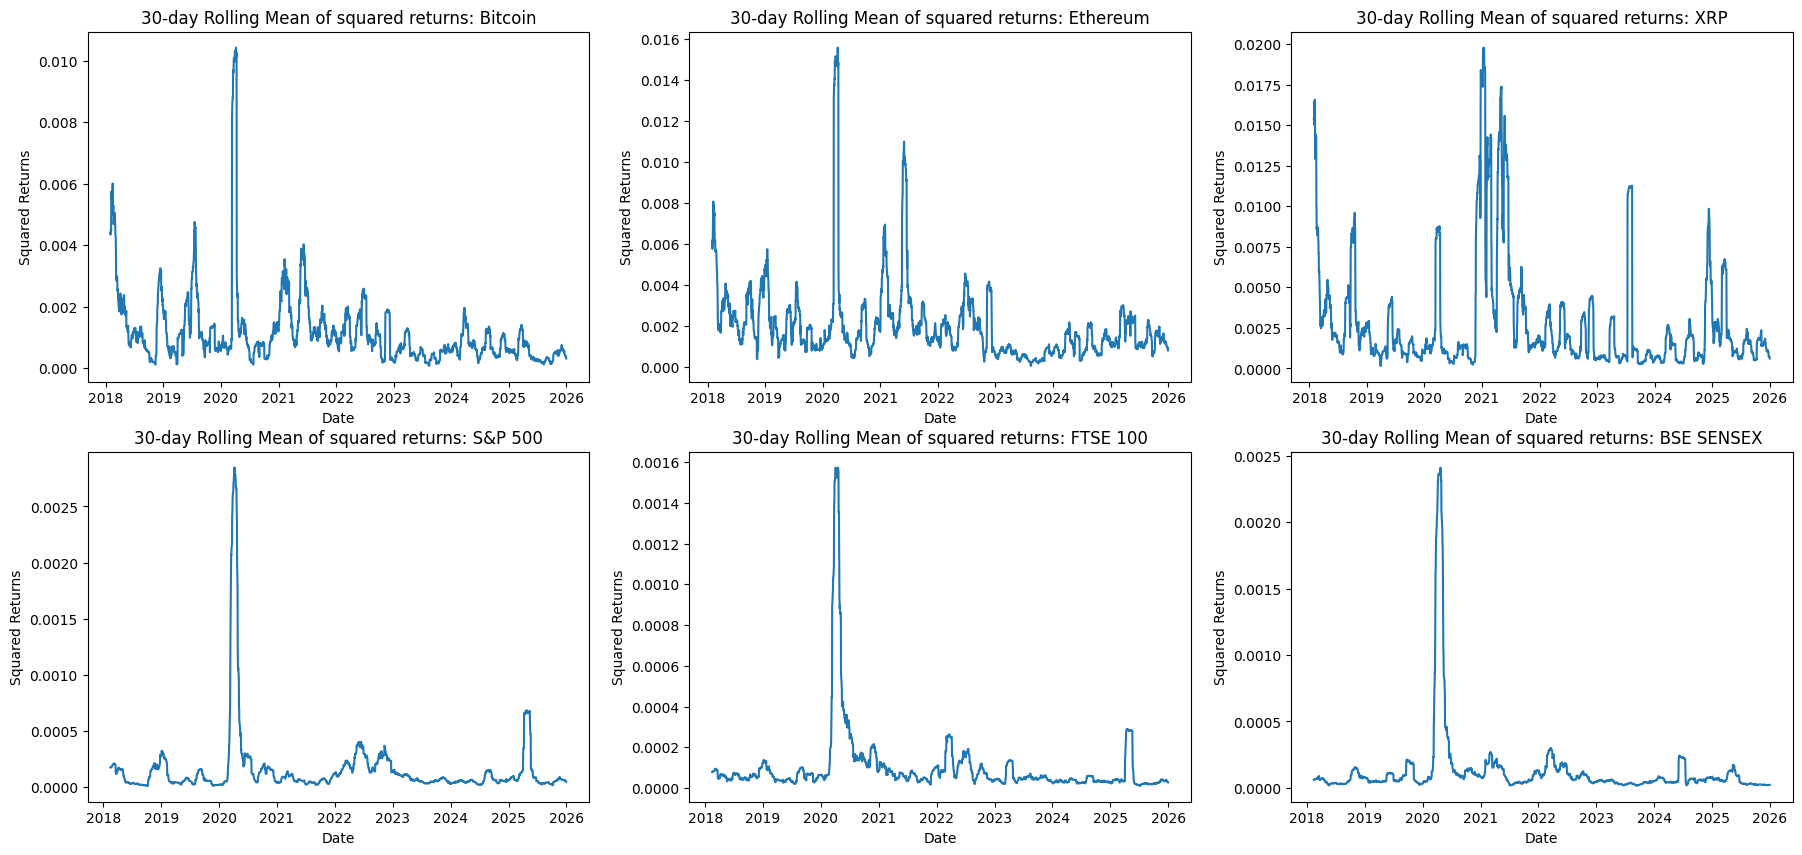

In [ ]:
#individual plot of square returns for each market
plt.figure(figsize=(22, 10))
plot_number = 1
for market in Markets:
  plt.subplot(2, 3, plot_number)
  plt.plot(df_squared_returns[market].dropna().rolling(30).mean())
  plt.title(f'30-day Rolling Mean of squared returns: {market}') # Add a title specific to each market
  plt.xlabel('Date')
  plt.ylabel('Squared Returns')
  plot_number +=1

plt.savefig('app1.png',
            dpi=300,
            bbox_inches = 'tight')

plt.show()

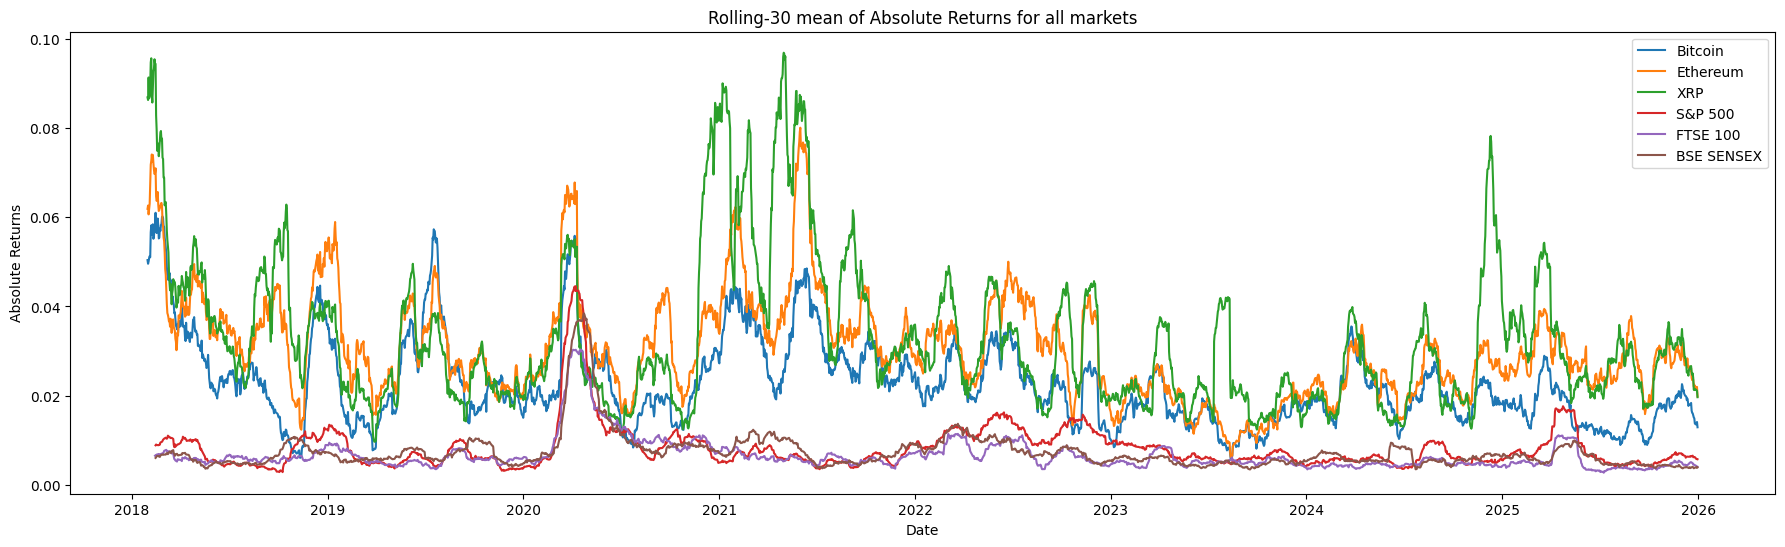

In [ ]:
#comparison plot of absolute returns
plt.figure(figsize=(22, 6)) # Set the figure size to make it wider
for market in Markets:
    rolling_absolute = df_absolute_returns[market].dropna().rolling(30).mean()
    plt.plot(rolling_absolute, label=market)
plt.title('Rolling-30 mean of Absolute Returns for all markets') # Add a title specific to each market
plt.xlabel('Date')
plt.ylabel('Absolute Returns')
plt.legend()
plt.savefig('fig2.png',
            dpi=300,
            bbox_inches = 'tight')

plt.show()

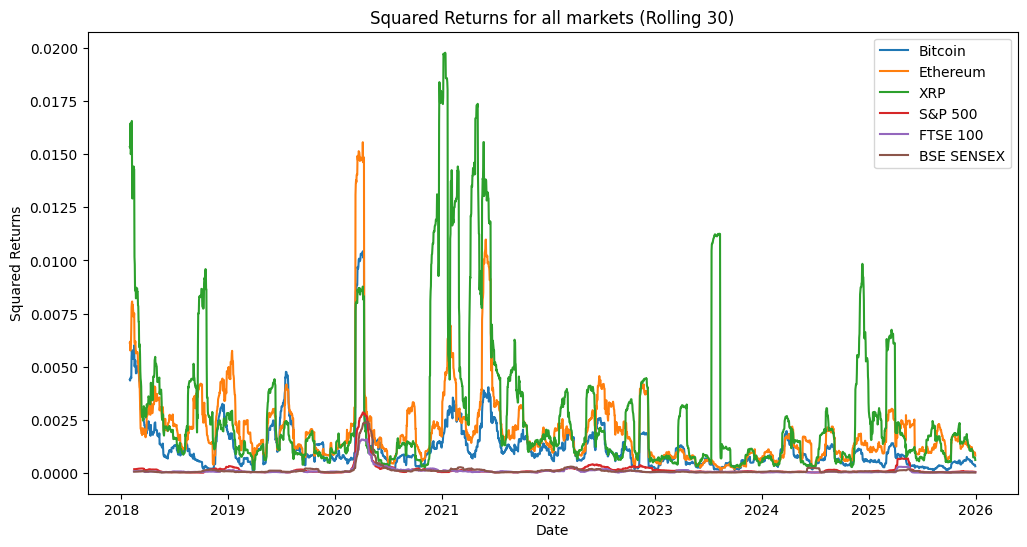

In [ ]:
#comparison plot of squared returns
plt.figure(figsize=(12, 6)) # Set the figure size to make it wider
for market in Markets:
    rolling_squared = df_squared_returns[market].dropna().rolling(30).mean()
    plt.plot(rolling_squared, label=market)
plt.title(f'Squared Returns for all markets (Rolling 30)') # Add a title specific to each market
plt.xlabel('Date')
plt.ylabel('Squared Returns')
plt.legend()
plt.savefig('app2.png',
            dpi=300,
            bbox_inches = 'tight')
plt.show()

2. Investigate volatility persistence and long memory

In [ ]:
#ACF plots
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

/tmp/ipykernel_2027/1399892316.py:6: FutureWarning: acf currently returns a plain tuple whose length depends on the qstat and alpha arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an AcfResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  abs_acf_values, confint = acf(


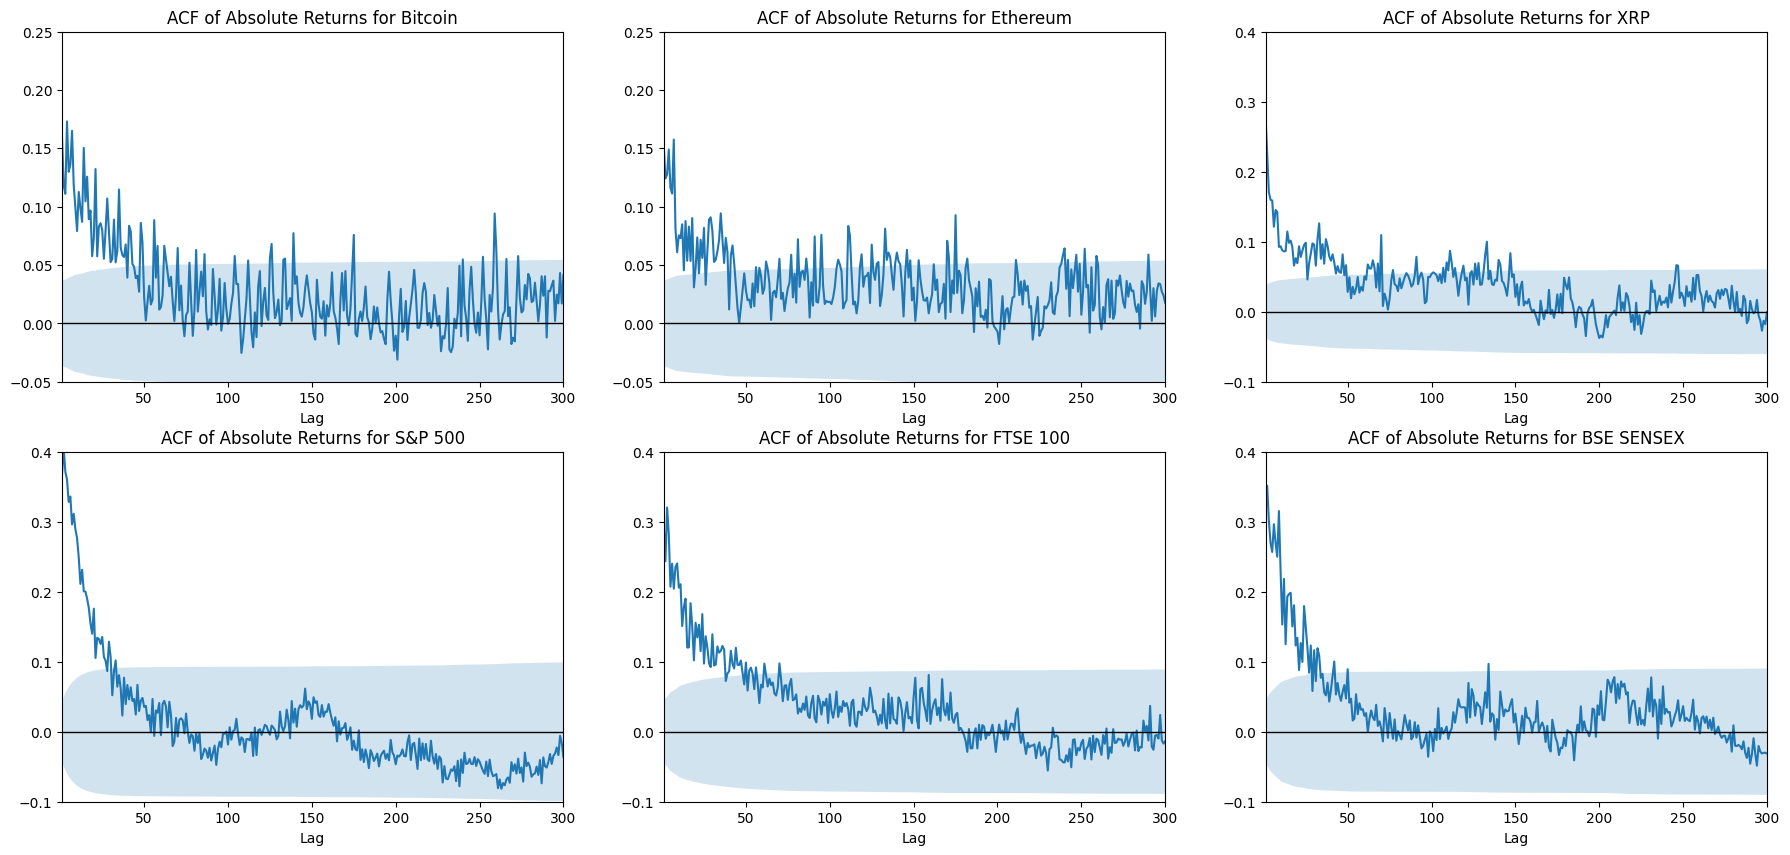

In [ ]:
#individual plots ACF of absolute returns
plt.figure(figsize=(22, 10))
plot_number = 1
for market in Markets:
  plt.subplot(2, 3, plot_number)
  abs_acf_values, confint = acf(
      df_absolute_returns[market].dropna(),
      nlags=300, alpha=0.05)
  #confidence intervals centered around zero
  lower = confint[:, 0] - abs_acf_values
  upper = confint[:, 1] - abs_acf_values
  lags = np.arange(len(abs_acf_values))

  plt.plot(abs_acf_values, linewidth=1.5)
  plt.fill_between(lags, lower, upper, alpha=0.2)

  plt.title(f'ACF of Absolute Returns for {market}')
  plt.xlabel('Lag')
  plt.xlim(1, 300)
  if market in ["Bitcoin", "Ethereum"]:
    plt.ylim(-0.05, 0.25)
  else:
    plt.ylim(-0.1, 0.4)
  plt.axhline(y=0, color='black', linewidth=1)
  plot_number +=1

plt.savefig('fig3.png',
            dpi=300,
            bbox_inches = 'tight')
plt.show()

/tmp/ipykernel_2027/3171902806.py:6: FutureWarning: acf currently returns a plain tuple whose length depends on the qstat and alpha arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an AcfResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  sq_acf_values, confint = acf(


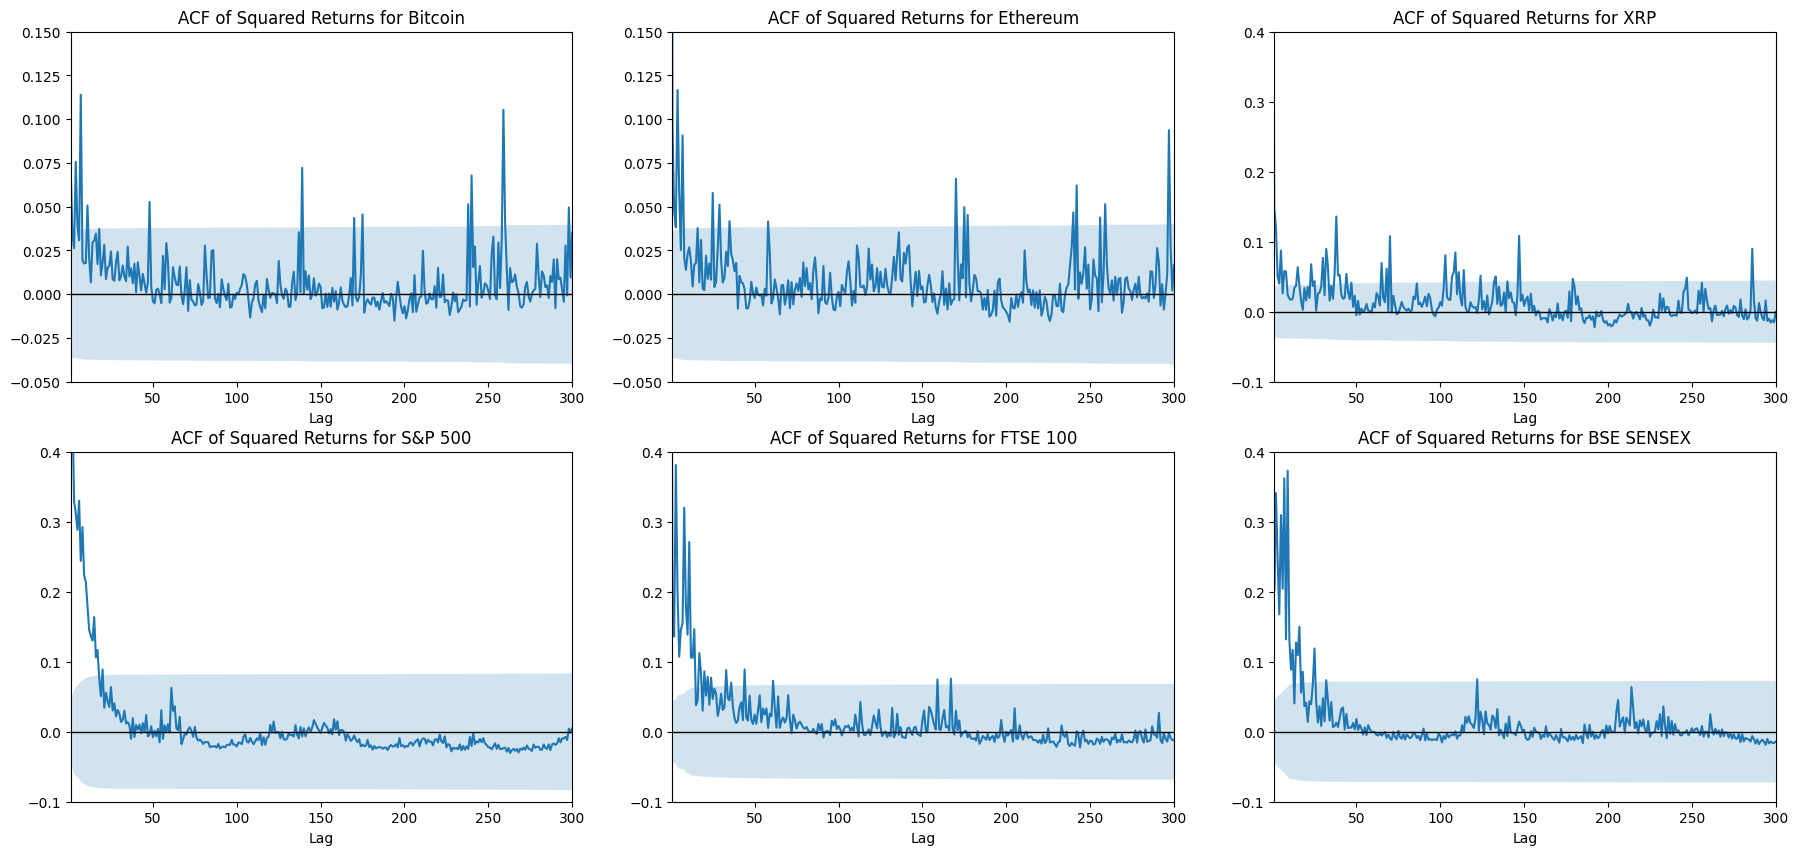

In [ ]:
#individual plots ACF of squared returns
plt.figure(figsize=(22, 10))
plot_number = 1
for market in Markets:
  plt.subplot(2, 3, plot_number)
  sq_acf_values, confint = acf(
      df_squared_returns[market].dropna(),
      nlags=300, alpha=0.05)
  #confidence intervals centered around zero
  lower = confint[:, 0] - sq_acf_values
  upper = confint[:, 1] - sq_acf_values
  lags = np.arange(len(sq_acf_values))

  plt.plot(sq_acf_values, linewidth=1.5)
  plt.fill_between(lags, lower, upper, alpha=0.2)

  plt.title(f'ACF of Squared Returns for {market}')
  plt.xlabel('Lag')
  plt.xlim(1, 300)
  if market in ["Bitcoin", "Ethereum"]:
    plt.ylim(-0.05, 0.15)
  else:
    plt.ylim(-0.1, 0.4)
  plt.axhline(y=0, color='black', linewidth=1)
  plot_number +=1

plt.savefig('app3.png',
            dpi=300,
            bbox_inches = 'tight')
plt.show()

In [ ]:

#ACF numerical comparison table
lags = [1, 5, 10, 20, 50, 100]

abs_acf_numerical = []

sq_acf_numerical = []

for market in Markets:
  #ACF of absolute returns
  acf_absolute = acf(df_absolute_returns[market].dropna(), nlags = 100)
  #ACF of squared returns
  acf_squared = acf(df_squared_returns[market].dropna(), nlags = 100)
  abs_acf_numerical.append({
        "Market": market,
        **{f"Lag {lag}": acf_absolute[lag] for lag in lags}
    })

  sq_acf_numerical.append({
        "Market": market,
        **{f"Lag {lag}": acf_squared[lag] for lag in lags}
    })

abs_acf_df = pd.DataFrame(abs_acf_numerical).round(4)
sq_acf_df = pd.DataFrame(sq_acf_numerical).round(4)

abs_acf_df.to_csv("absolute_acf_table.csv", index=False)
sq_acf_df.to_csv("squared_acf_table.csv", index=False)
abs_acf_df

,Market,Lag 1,Lag 5,Lag 10,Lag 20,Lag 50,Lag 100
0,Bitcoin,0.1610,0.1300,0.0792,0.0735,0.0221,-0.0004
1,Ethereum,0.1528,0.1162,0.0754,0.0471,0.0283,0.0185
2,XRP,0.2811,0.1589,0.0935,0.0693,0.0283,0.0541
3,S&P 500,0.3663,0.3283,0.2765,0.1758,0.0354,-0.0182
4,FTSE 100,0.2938,0.2072,0.2058,0.1557,0.0988,0.0537
5,BSE SENSEX,0.3113,0.2568,0.2295,0.1340,0.0893,-0.0039


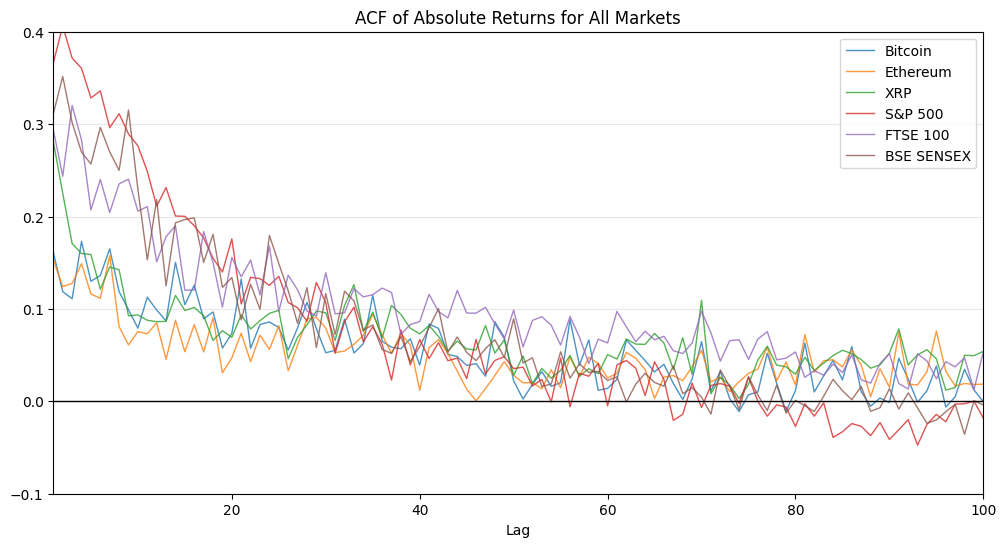

In [ ]:
#combined ACF plot of absolute returns
plt.figure(figsize=(12, 6)) # Set the figure size to make it wider

for market in Markets:
  abs_acf_values = acf(
      df_absolute_returns[market].dropna(),
      nlags=100)

  lags = np.arange(len(abs_acf_values))


  plt.plot(abs_acf_values, linewidth=1, label=market, alpha=0.8)

plt.title(f'ACF of Absolute Returns for All Markets')
plt.xlabel('Lag')
plt.xlim(1,100)
plt.axhline(y=0, color='black', linewidth=1)
plt.ylim(-0.1, 0.4)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

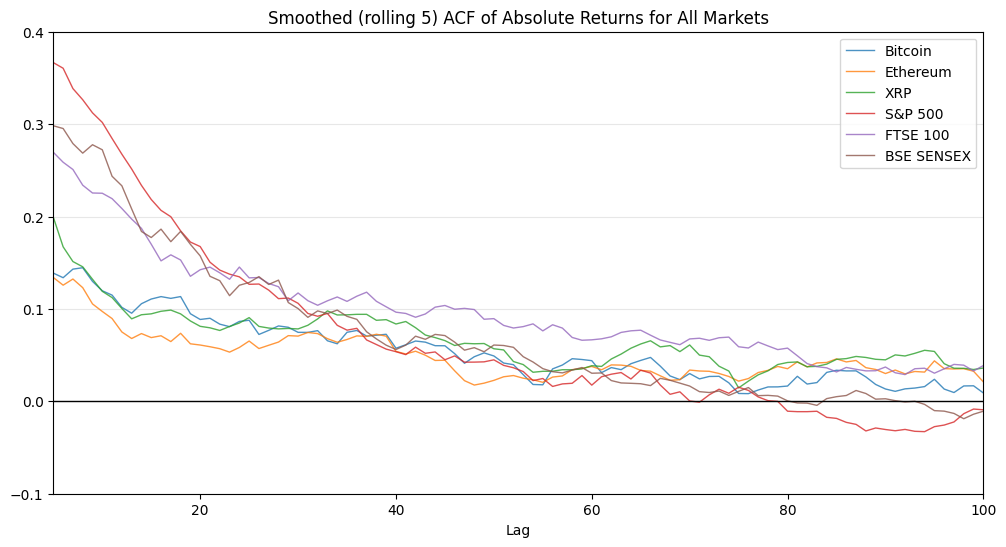

In [ ]:
#smoothed combined ACF plot of absolute returns
plt.figure(figsize=(12, 6)) # Set the figure size to make it wider

for market in Markets:
  abs_acf_values = acf(
      df_absolute_returns[market].dropna(),
      nlags=100)

  lags = np.arange(len(abs_acf_values))
  smoothed_abs_acf = pd.Series(abs_acf_values).rolling(5).mean()

  plt.plot(smoothed_abs_acf, linewidth=1, label=market, alpha=0.8)

plt.title(f'Smoothed (rolling 5) ACF of Absolute Returns for All Markets')
plt.xlabel('Lag')
plt.xlim(5,100)
plt.axhline(y=0, color='black', linewidth=1)
plt.ylim(-0.1, 0.4)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

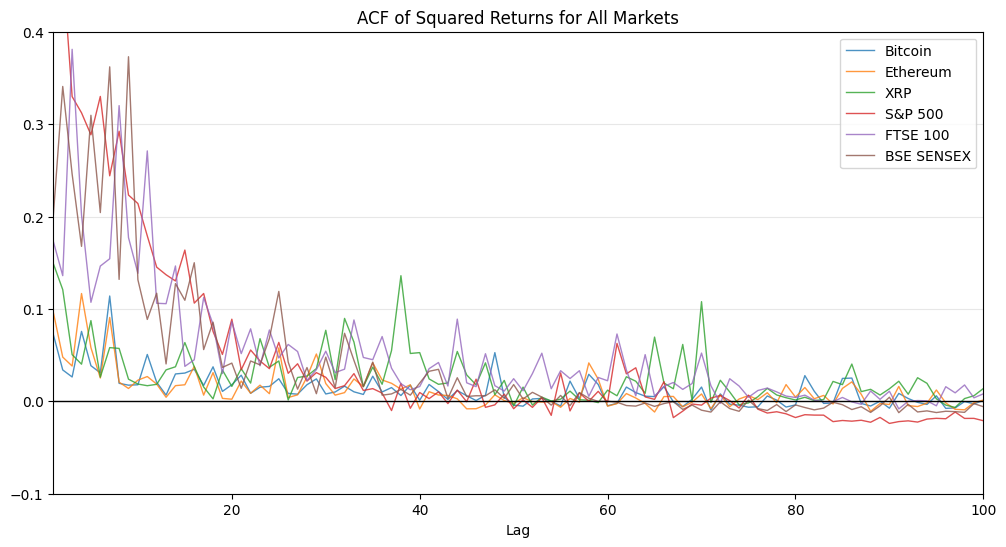

In [ ]:
#combined ACF plot of squared returns
plt.figure(figsize=(12, 6)) # Set the figure size to make it wider

for market in Markets:
  sq_acf_values = acf(
      df_squared_returns[market].dropna(),
      nlags=100)

  lags = np.arange(len(sq_acf_values))


  plt.plot(sq_acf_values, linewidth=1, label=market, alpha=0.8)

plt.title(f'ACF of Squared Returns for All Markets')
plt.xlabel('Lag')
plt.xlim(1,100)
plt.axhline(y=0, color='black', linewidth=1)
plt.ylim(-0.1, 0.4)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

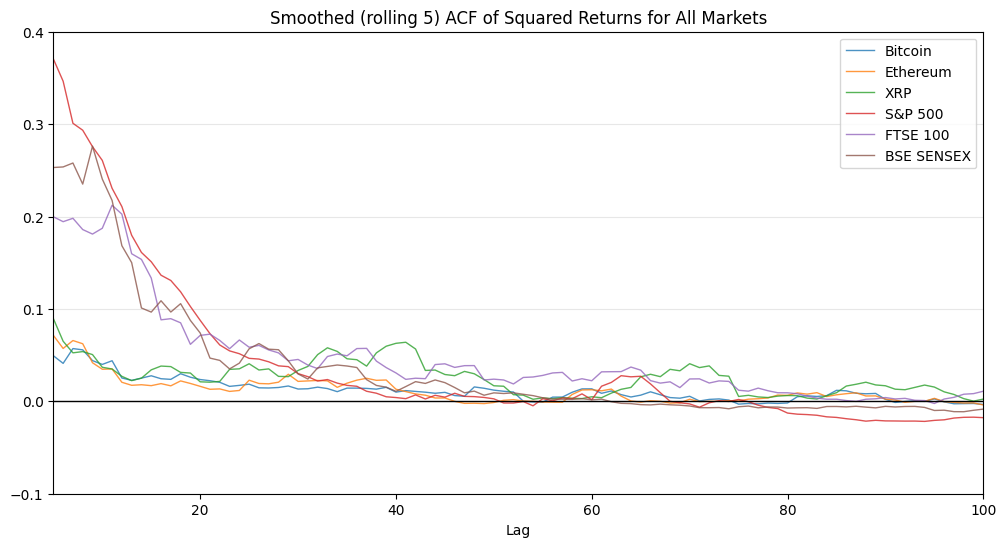

In [ ]:
#smoothed combined ACF plot of squared returns
plt.figure(figsize=(12, 6)) # Set the figure size to make it wider

for market in Markets:
  sq_acf_values = acf(
      df_squared_returns[market].dropna(),
      nlags=100)

  lags = np.arange(len(sq_acf_values))

  smoothed_sq_acf = pd.Series(sq_acf_values).rolling(5).mean()

  plt.plot(smoothed_sq_acf, linewidth=1, label=market, alpha=0.8)

plt.title(f'Smoothed (rolling 5) ACF of Squared Returns for All Markets')
plt.xlabel('Lag')
plt.xlim(5,100)
plt.axhline(y=0, color='black', linewidth=1)
plt.ylim(-0.1, 0.4)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

3. Investigate tail behaviour



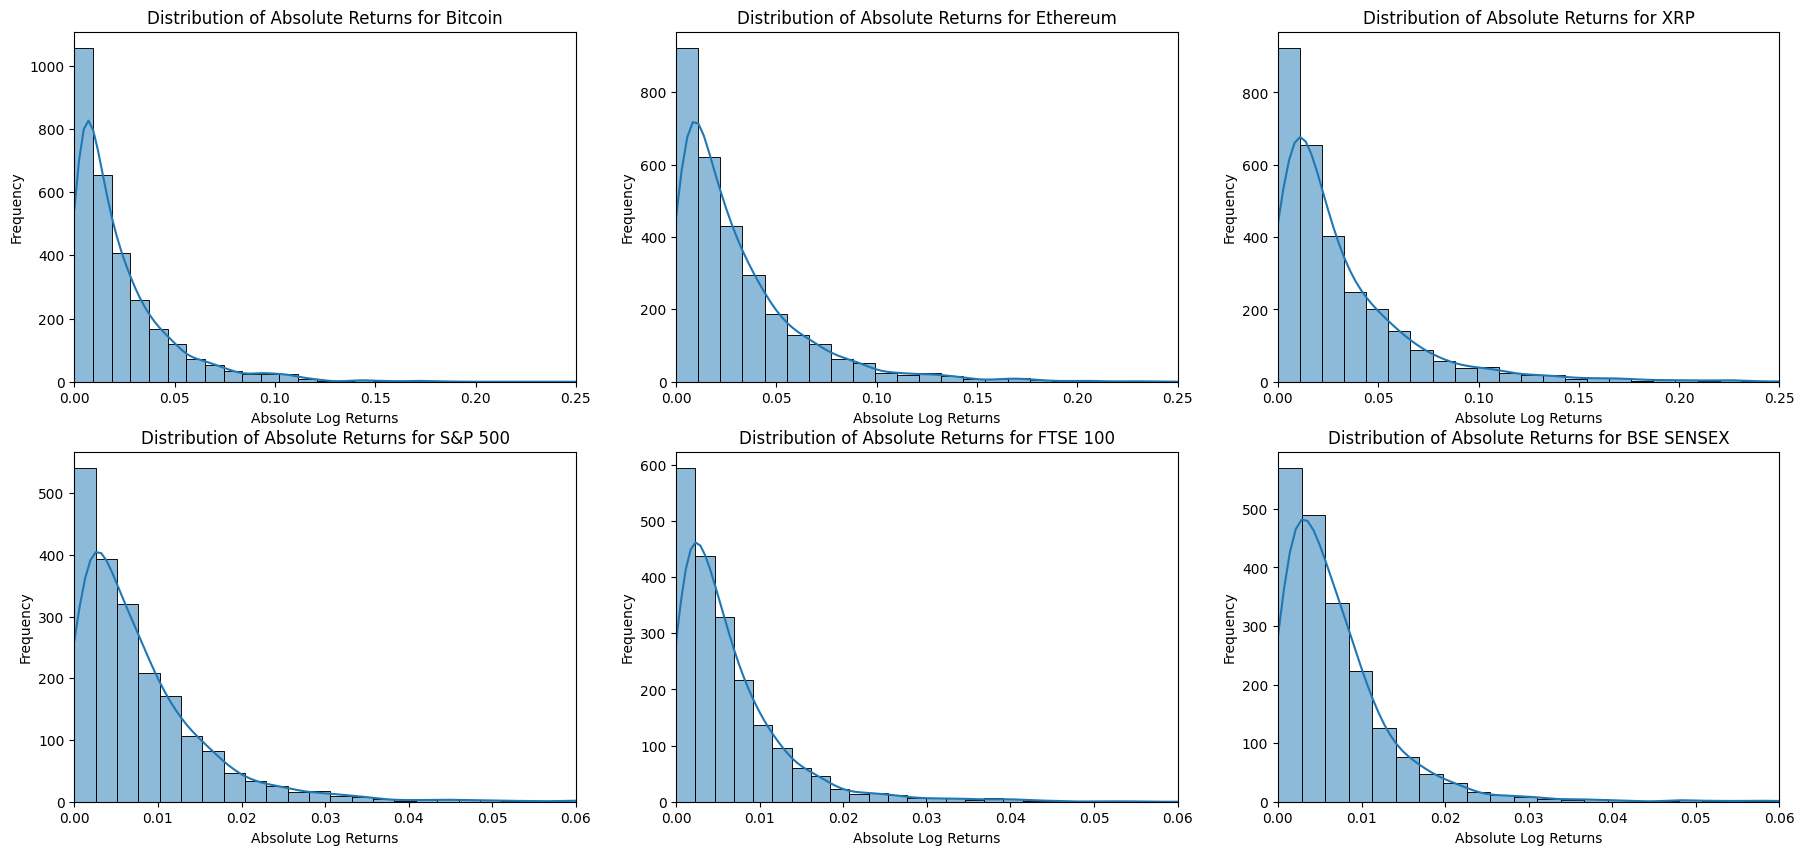

In [ ]:
#using absolute returns - direct measure of magnitude of returns
#squared returns less intuitive

#histograms of absolute returns for each market
plt.figure(figsize=(22, 10))
plot_number = 1
for market in Markets:
  plt.subplot(2, 3, plot_number)
  sns.histplot(df_absolute_returns[market].dropna(), bins=50, kde=True)
  plt.title(f'Distribution of Absolute Returns for {market}')
  plt.xlabel('Absolute Log Returns')
  plt.ylabel('Frequency')
  if market in ["Bitcoin", "Ethereum", "XRP"]:
    plt.xlim(0, 0.25)
  else:
    plt.xlim(0, 0.06)
  plot_number +=1

plt.savefig('fig4.png',
            dpi=300,
            bbox_inches = 'tight')
plt.show()

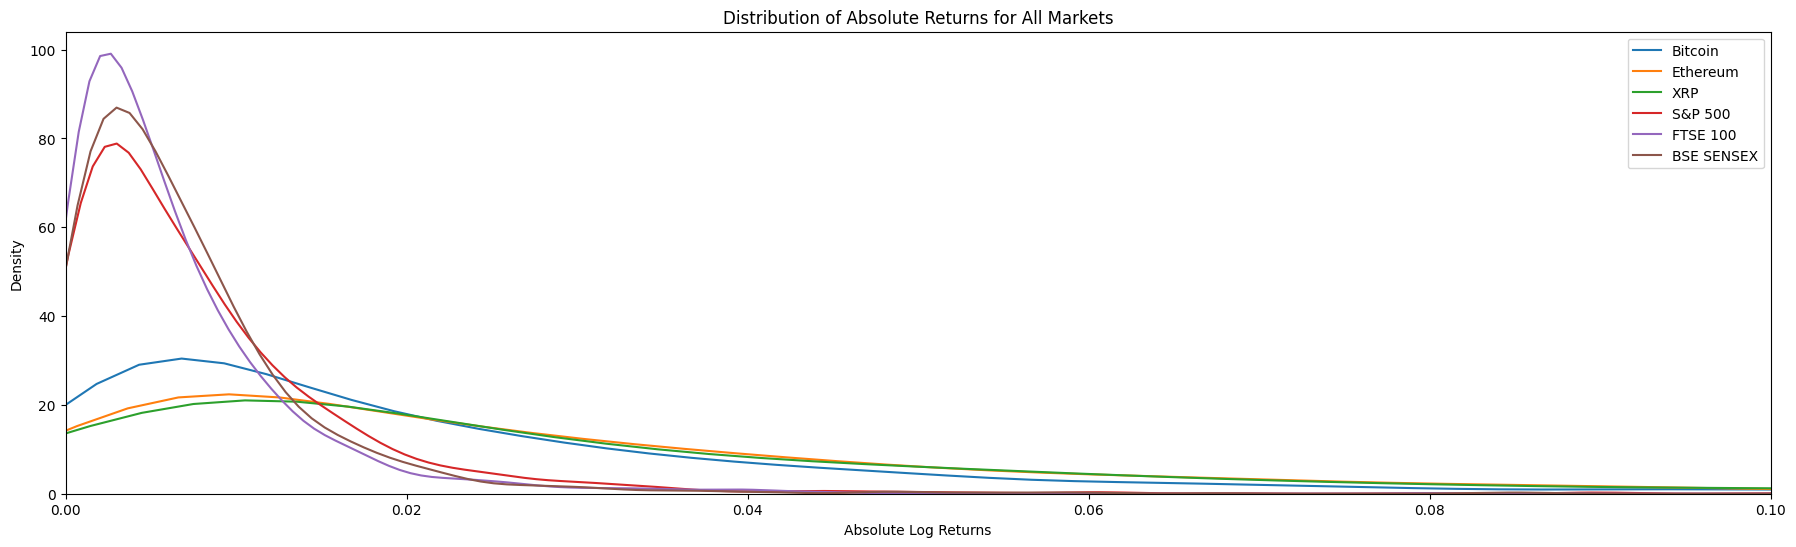

In [ ]:
#comparative kde plot of absolute returns
plt.figure(figsize=(22, 6))
for market in Markets:
    sns.kdeplot(df_absolute_returns[market].dropna(), label=market)
plt.title(f'Distribution of Absolute Returns for All Markets')
plt.xlabel('Absolute Log Returns')
plt.ylabel('Density')
plt.legend()
plt.xlim(0, 0.1)
plt.savefig('fig5.png',
            dpi=300,
            bbox_inches = 'tight')
plt.show()

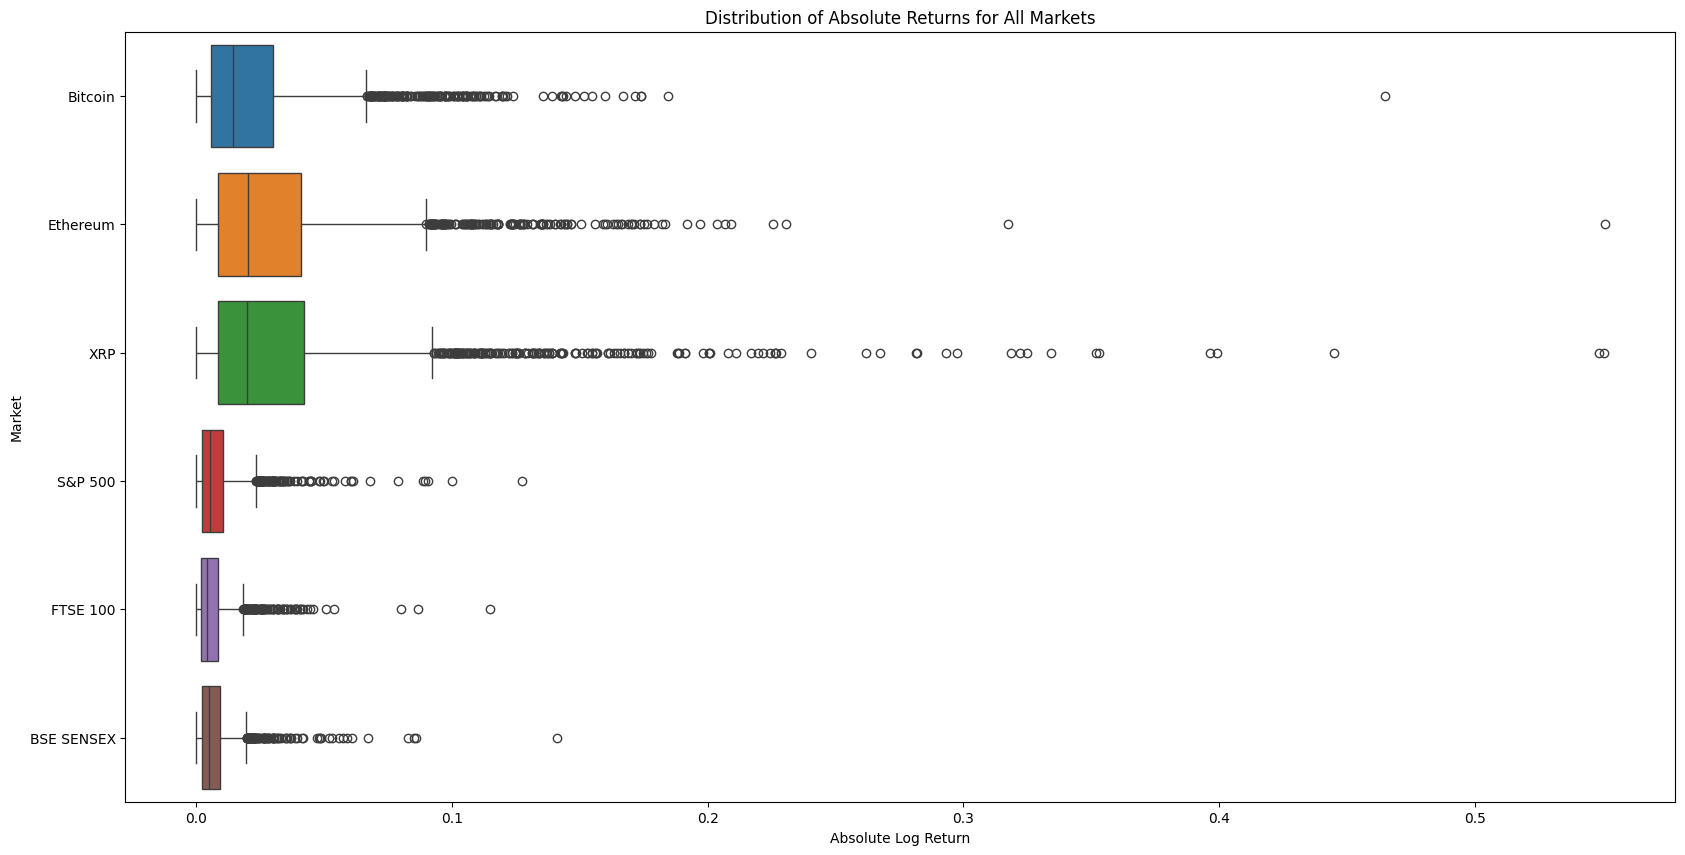

In [ ]:
plt.figure(figsize=(20,10))

sns.boxplot(df_absolute_returns, orient="h")
plt.title(f'Distribution of Absolute Returns for All Markets')
plt.ylabel('Market')
plt.xlabel('Absolute Log Return')

plt.show()

In [ ]:
#identify extreme values
extreme_returns = []

for market in Markets:
  largest = df_absolute_returns[market].nlargest(2)
  for date, value in largest.items():
    extreme_returns.append({
        "Market": market,
        "Date": date,
        "Absolute Return": value
    })
extreme_returns_df = pd.DataFrame(extreme_returns)
extreme_returns_df.round(4)

,Market,Date,Absolute Return
0,Bitcoin,2020-03-12,0.4647
1,Bitcoin,2018-01-16,0.1846
2,Ethereum,2020-03-12,0.5507
3,Ethereum,2021-05-19,0.3175
4,XRP,2020-12-23,0.5505
5,XRP,2023-07-13,0.5486
6,S&P 500,2020-03-16,0.1277
7,S&P 500,2020-03-12,0.0999
8,FTSE 100,2020-03-12,0.1151
9,FTSE 100,2020-03-24,0.0867


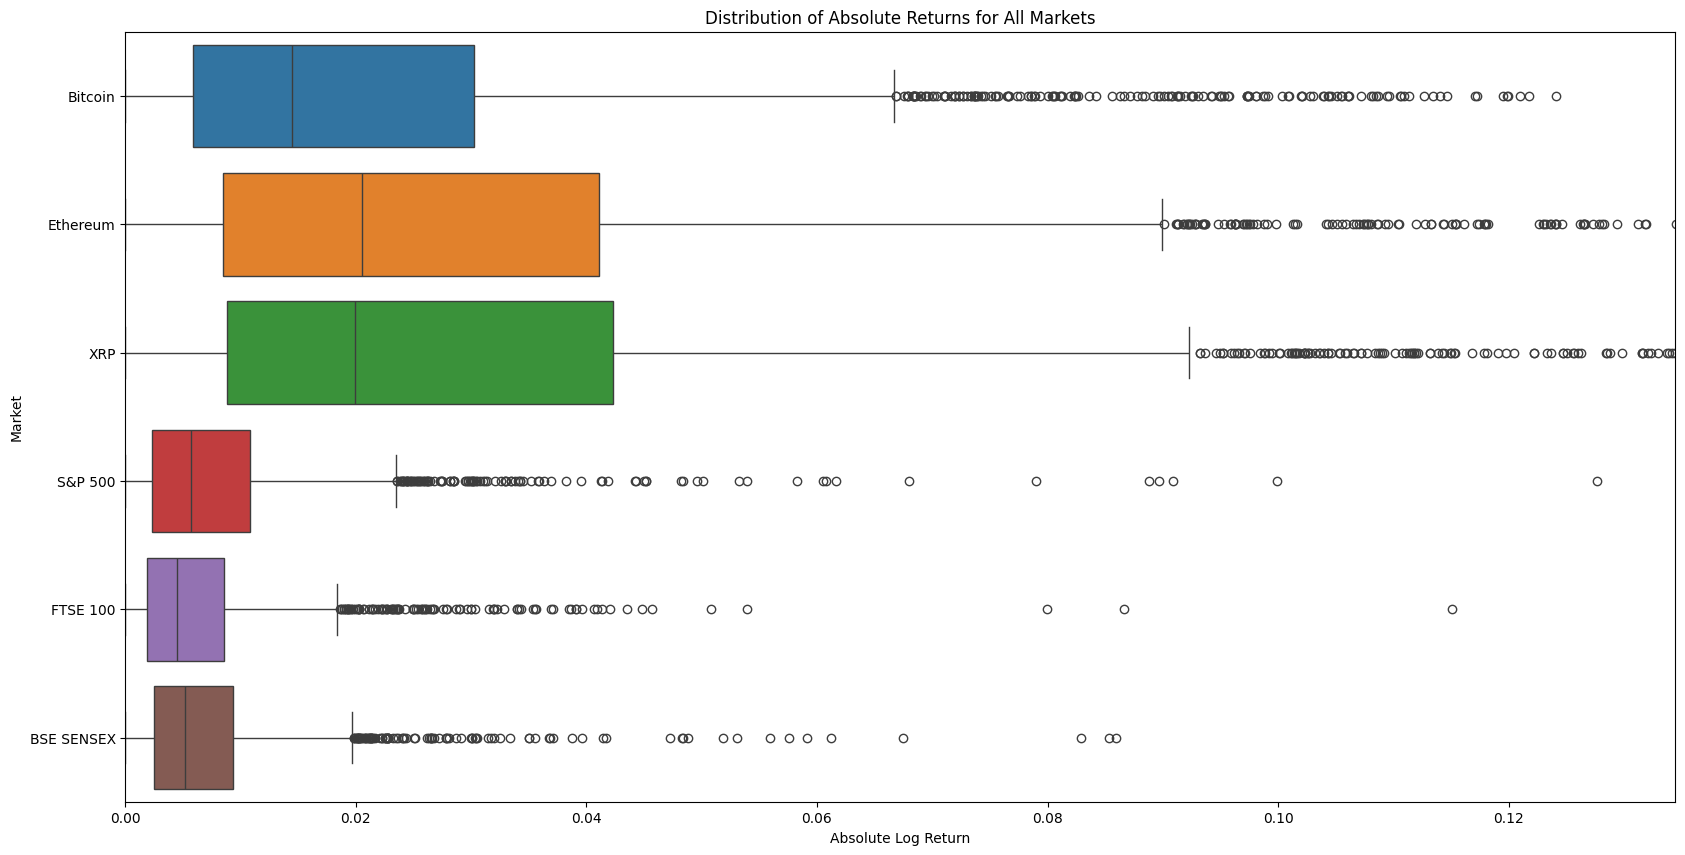

In [ ]:
#zoom in on boxplot to improve clarity
zoom_limit = df_absolute_returns.stack().quantile(0.99)
plt.figure(figsize=(20, 10))

sns.boxplot(df_absolute_returns, orient="h")
plt.title(f'Distribution of Absolute Returns for All Markets')
plt.ylabel('Market')
plt.xlabel('Absolute Log Return')
plt.xlim(0, zoom_limit)

plt.show()

In [ ]:
#calculate skewness and kurtosis
tail_stats = []



for market in Markets:
  series = df_absolute_returns[market].dropna()
  tail_stats.append({
    "Market": market,
    "Skewness": series.skew(),
    "Kurtosis": series.kurt(),
    "95th Percentile": series.quantile(0.95),
    "99th Percentile": series.quantile(0.99),
    "Max": series.max()
})
tail_stats_df = pd.DataFrame(tail_stats).round(4)
tail_stats_df.to_csv("tail_stats_table.csv", index=False)

In [ ]:
for market in Markets:
    print(f"\n{market}")
    print(df_absolute_returns[market].dropna().nlargest(10))


Bitcoin
Date
2020-03-12    0.464730
2018-01-16    0.184582
2022-06-13    0.174053
2018-02-05    0.173982
2021-02-08    0.171821
2020-03-19    0.167104
2019-04-02    0.160042
2022-11-09    0.154890
2019-06-27    0.151820
2021-05-19    0.148107
Name: Bitcoin, dtype: float64

Ethereum
Date
2020-03-12    0.550732
2021-05-19    0.317459
2021-01-03    0.230695
2021-05-24    0.225649
2021-01-21    0.209000
2018-09-05    0.206860
2018-01-16    0.203831
2025-05-08    0.197200
2022-11-09    0.191844
2019-09-24    0.183255
Name: Ethereum, dtype: float64

XRP
Date
2020-12-23    0.550503
2023-07-13    0.548555
2021-01-30    0.444756
2020-03-12    0.398968
2021-05-19    0.396244
2021-04-05    0.352960
2018-01-16    0.351975
2020-11-21    0.334399
2020-11-23    0.324814
2018-09-20    0.322005
Name: XRP, dtype: float64

S&P 500
Date
2020-03-16    0.127652
2020-03-12    0.099945
2025-04-09    0.090895
2020-03-24    0.089683
2020-03-13    0.088808
2020-03-09    0.079010
2020-04-06    0.067968
2025-04-0

# **Research Question 2**

In [ ]:
!pip install arch
from arch import arch_model

#GARCH model
#define function
def garch_model(market):
  #turn decimals to percentages for a more convenient scale
  data = market_returns[market].dropna() * 100
  #Fit GARCH model
  gm = arch_model(data, vol='Garch', p=1, q=1)
  res = gm.fit(disp='off')
  return res

#EGARCH model
def egarch_model(market):
  #turn decimals to percentages for a more convenient scale
  data = market_returns[market].dropna() * 100
  #Fit EGARCH model
  em = arch_model(data, vol='EGARCH', p=1, o=1, q=1)
  res = em.fit(disp='off')
  return res

#FIGARCH model
def figarch_model(market):
  #turn decimals to percentages for a more convenient scale
  data = market_returns[market].dropna() * 100
  #Fit FIGARCH model
  fm = arch_model(data, vol='FIGARCH', p=1, q=1)
  res = fm.fit(disp='off')
  return res

1. How well each model captures volatility dynamics

In [ ]:
#model parameters
models = {
    "GARCH": garch_model,
    "EGARCH": egarch_model,
    "FIGARCH": figarch_model
}

fitted_models = {}

for market in Markets:
  fitted_models[market] = {}
  for model_name, model_func in models.items():
    fitted_models[market][model_name] = model_func(market)



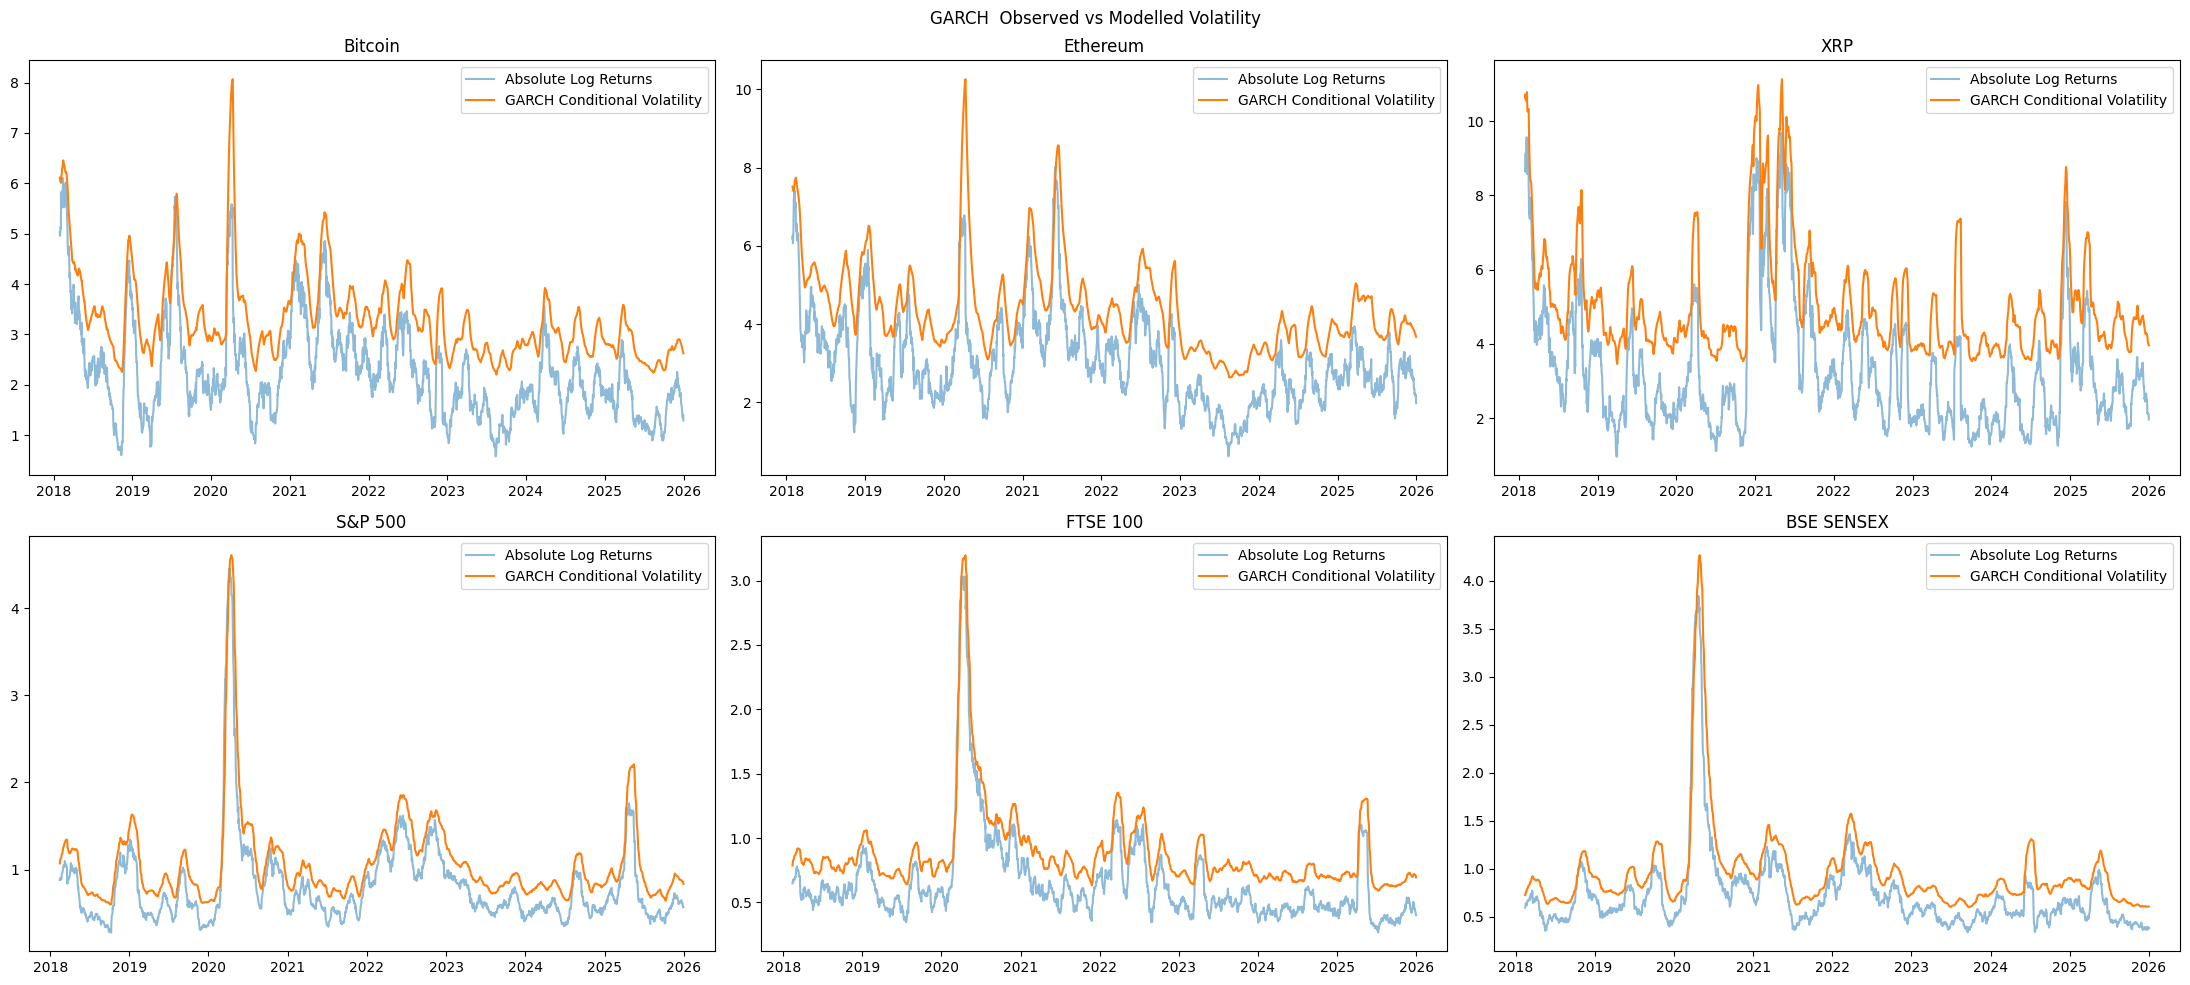

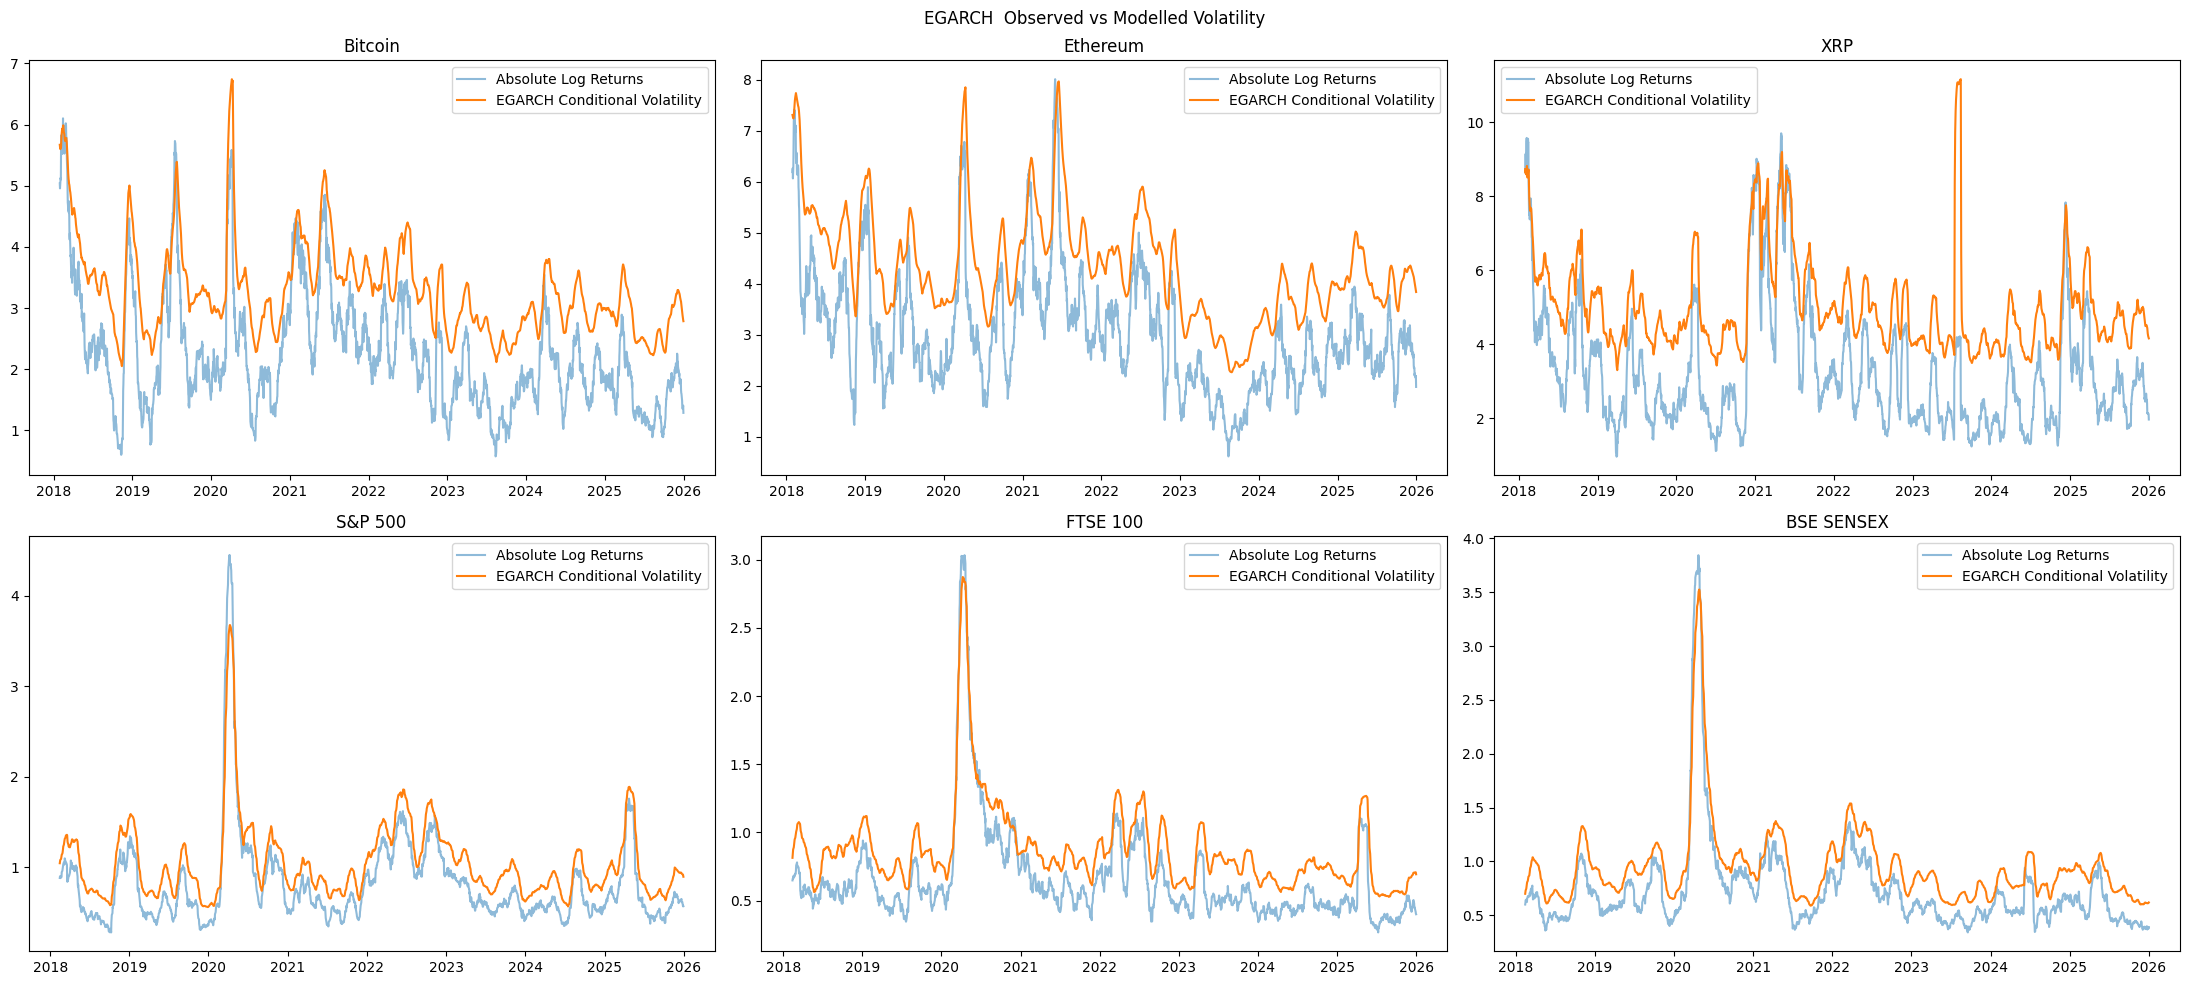

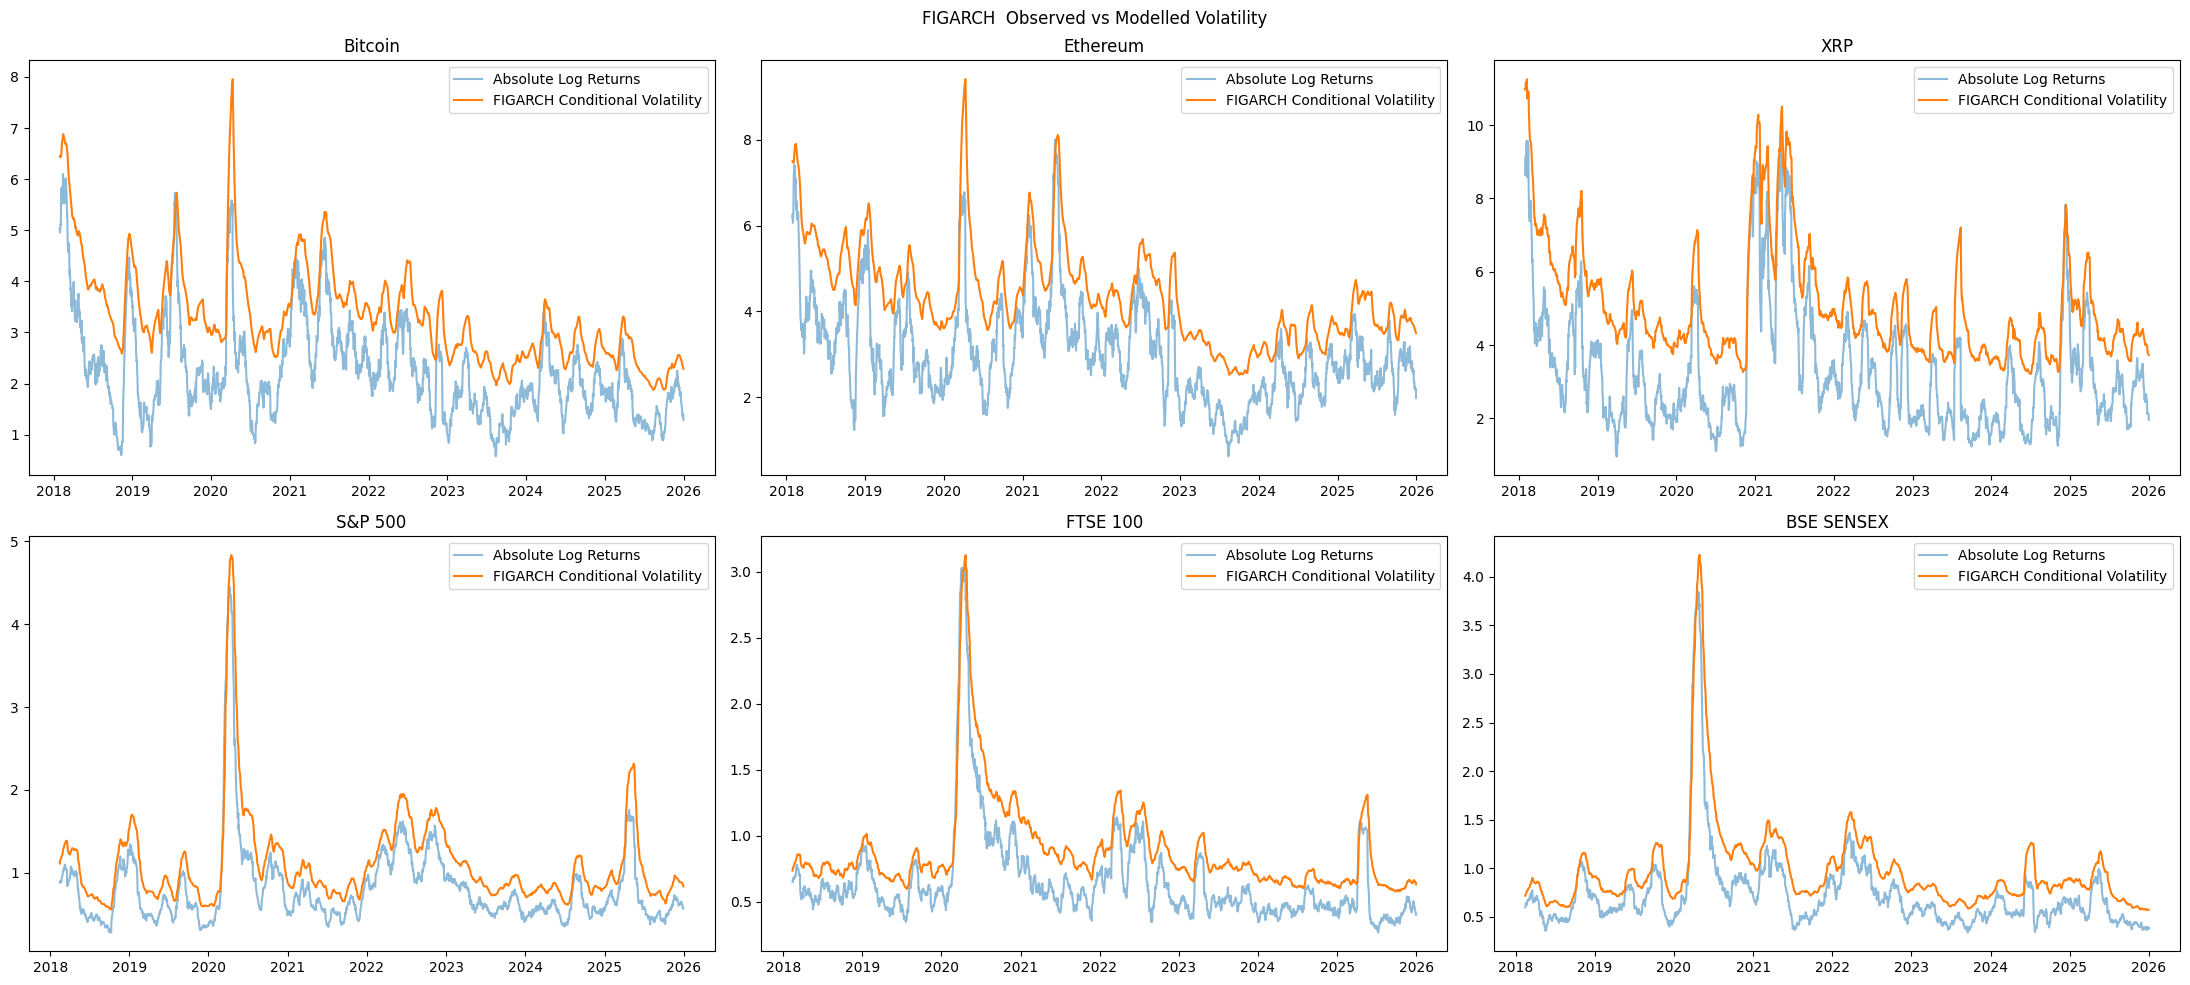

In [ ]:
#plot conditional volatility against observed volatility
for model in models:

  plt.figure(figsize=(22, 10)) # Set the figure size to make it wider
  plot_number = 1
  for market in Markets:

    #use absolute returns as observed volatility
    observed = market_returns[market].abs() * 100
    fitted = fitted_models[market][model].conditional_volatility

    observed_rolling = observed.rolling(30).mean()
    fitted_rolling = fitted.rolling(30).mean()

    #2x3 grid
    plt.subplot(2, 3, plot_number)

    plt.plot(observed_rolling, label = "Absolute Log Returns", alpha = 0.5)
    plt.plot(fitted_rolling, label = f"{model} Conditional Volatility")

    plt.title(f"{market}")
    plt.legend()

    plot_number += 1
  plt.suptitle(f"{model}  Observed vs Modelled Volatility")
  plt.tight_layout()
  plt.savefig(f'{model}_model_plot.png',
              dpi=300,
              bbox_inches='tight')
  plt.show()


In [ ]:
#GARCH model parameter - shock response and persistence
garch_params = []

for market in Markets:
  res = fitted_models[market]["GARCH"]
  garch_params.append({
        "Market": market,
        "Alpha": res.params["alpha[1]"],
        "Alpha p-value": res.pvalues["alpha[1]"],
        "Beta": res.params["beta[1]"],
        "Beta p-value": res.pvalues["beta[1]"],
        "Alpha + Beta": res.params["alpha[1]"] + res.params["beta[1]"]
    })
garch_params_df = pd.DataFrame(garch_params).round(4)
garch_params_df.to_csv("garch_params_table.csv", index=False)


In [ ]:
#EGARCH model parameters
egarch_params = []

for market in Markets:
  res = fitted_models[market]["EGARCH"]
  egarch_params.append({
        "Market": market,
        "Alpha": res.params["alpha[1]"],
        "Alpha p-value": res.pvalues["alpha[1]"],
        "Gamma": res.params["gamma[1]"],
        "Gamma p-value": res.pvalues["gamma[1]"],
        "Beta": res.params["beta[1]"],
        "Beta p-value": res.pvalues["beta[1]"],

    })
egarch_params_df = pd.DataFrame(egarch_params).round(4)
egarch_params_df.to_csv("egarch_params_table.csv", index=False)

In [ ]:
#FIGARCH model parameters
figarch_params = []

for market in Markets:
  res = fitted_models[market]["FIGARCH"]
  figarch_params.append({
        "Market": market,
        "Mu": res.params["mu"],
        "Mu p-value": res.pvalues["mu"],
        "Omega": res.params["omega"],
        "Omega p-value": res.pvalues["omega"],
        "Phi": res.params["phi"],
        "Phi p-value": res.pvalues["phi"],
        "d": res.params["d"],
        "d p-value": res.pvalues["d"],
        "Beta": res.params["beta"],
        "Beta p-value": res.pvalues["beta"]
    })
figarch_params_df = pd.DataFrame(figarch_params).round(4)
figarch_params_df.to_csv("figarch_params_table.csv", index=False)

2. How well can models forecast volatility

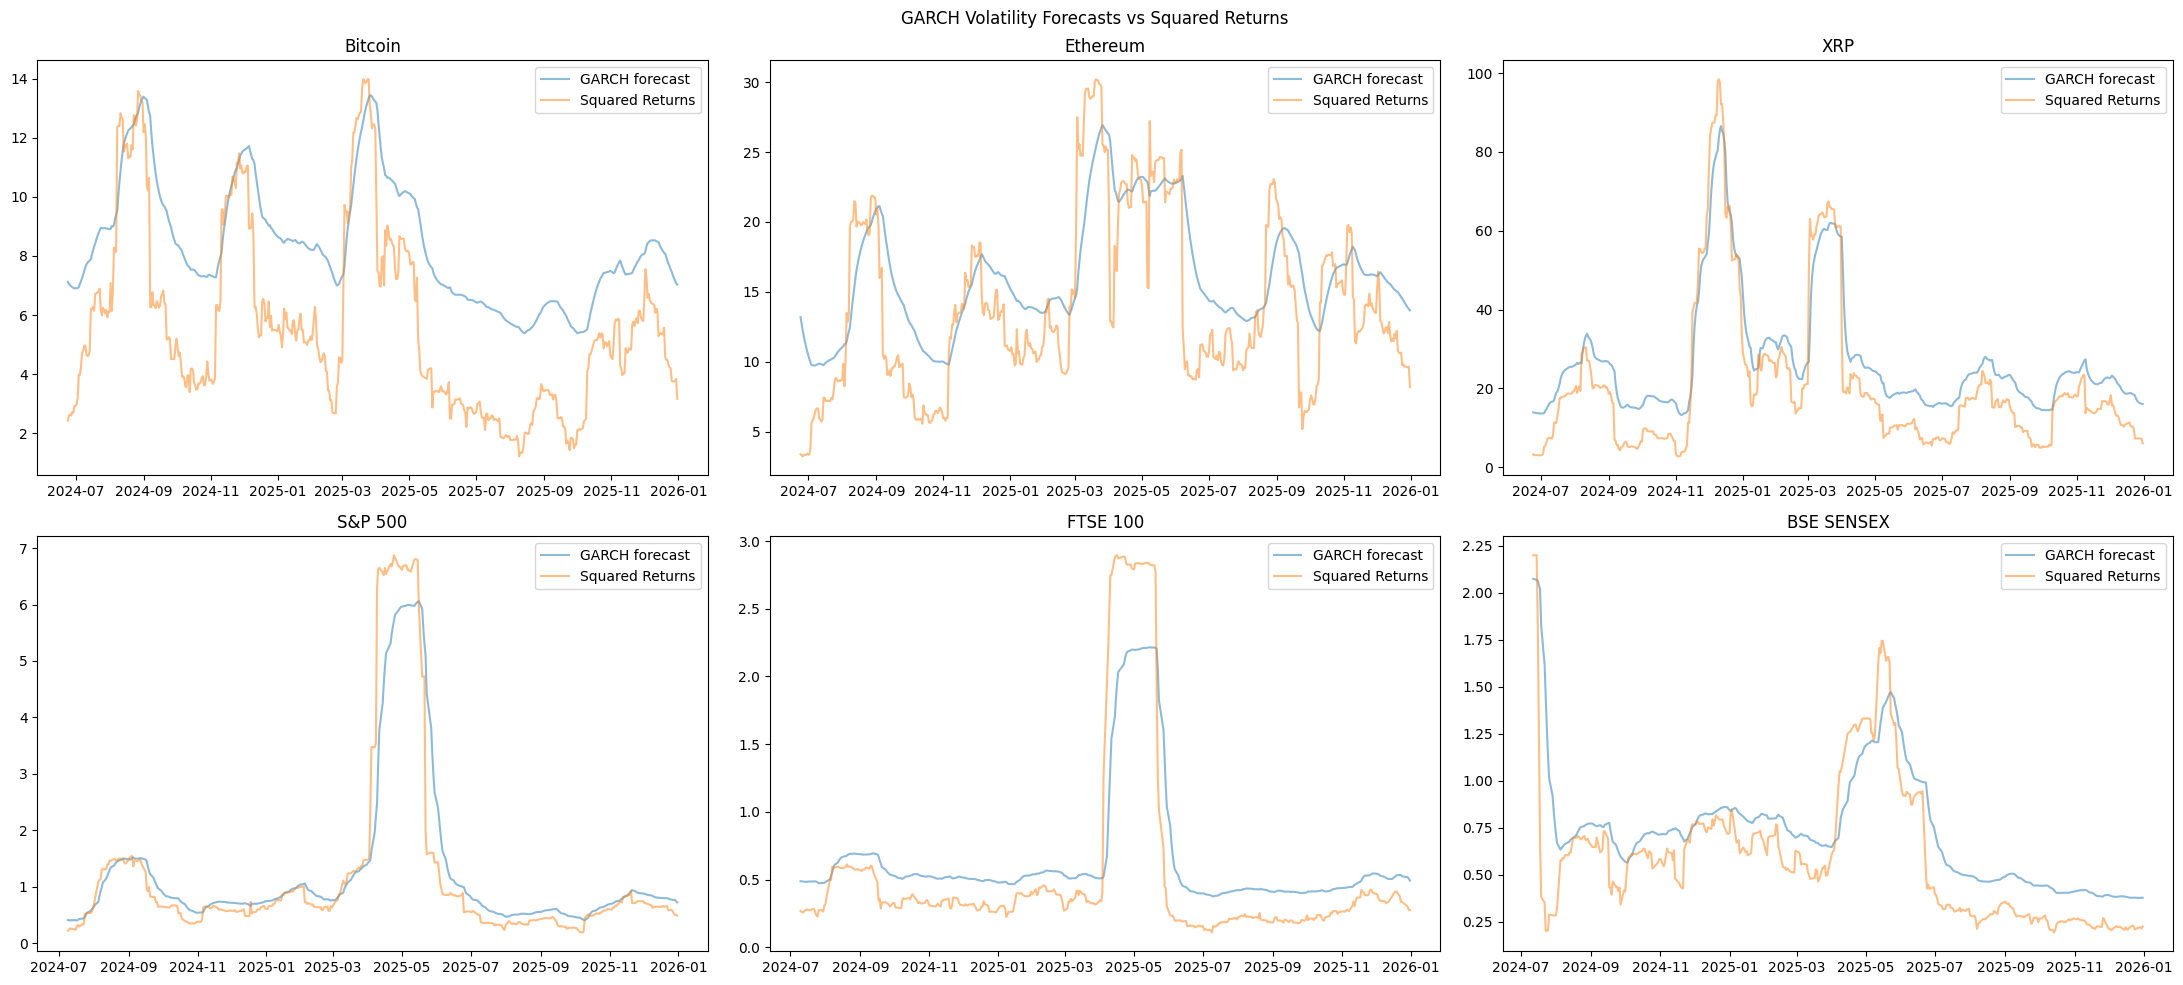

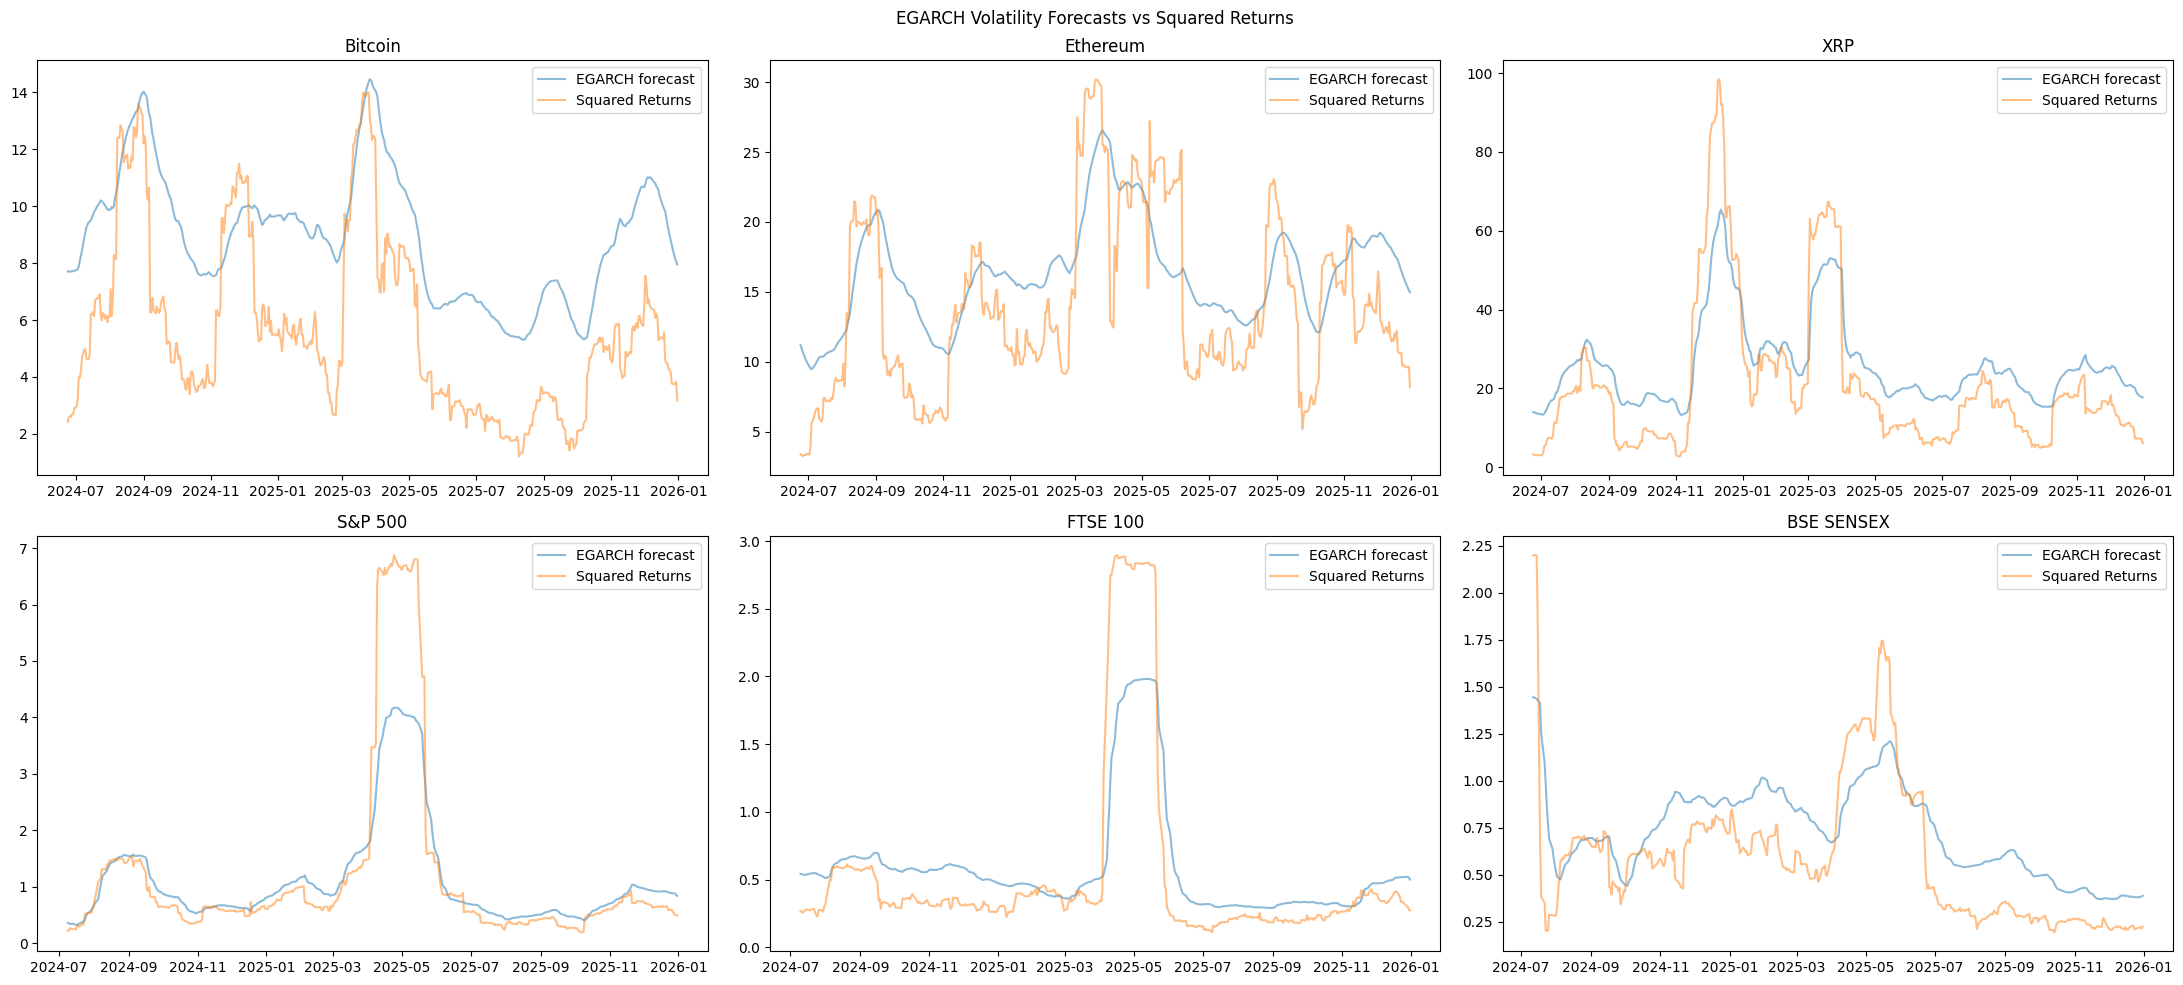

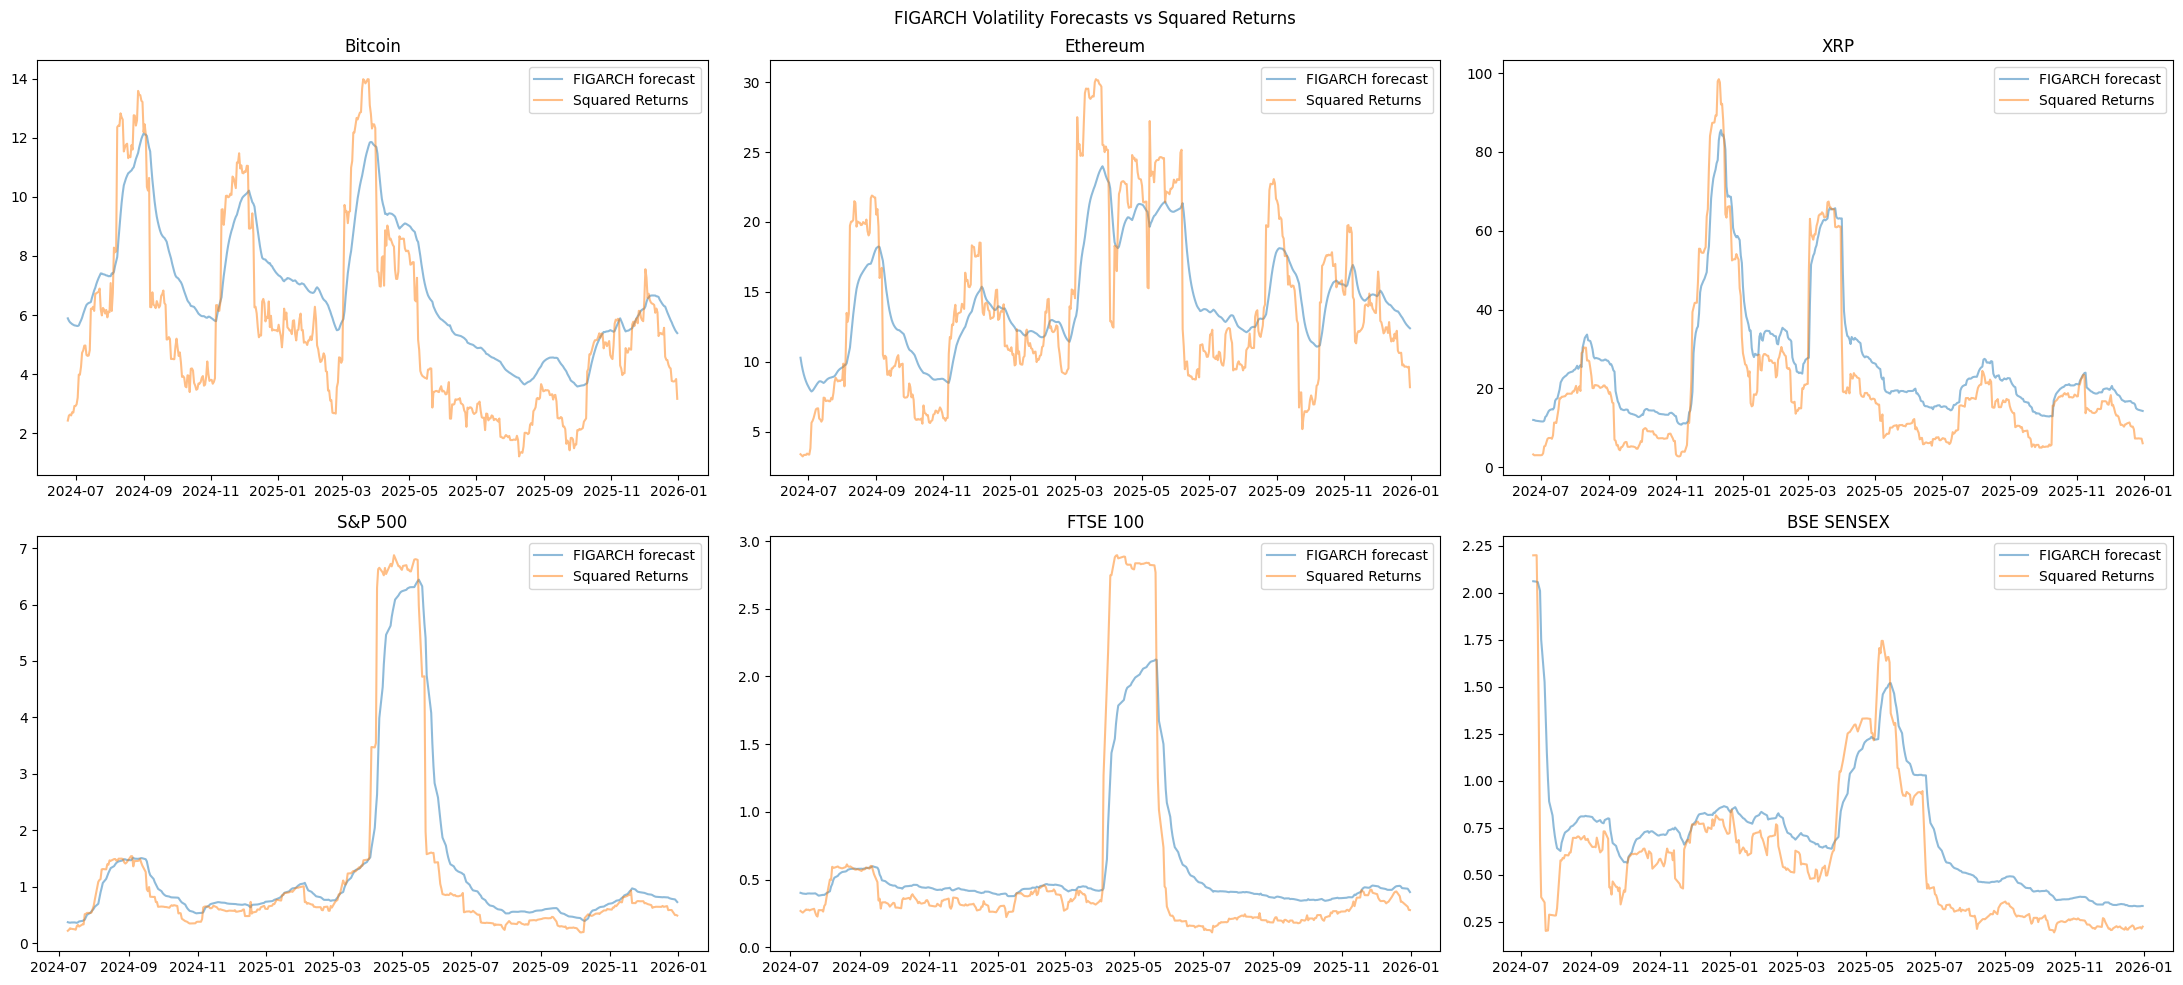

In [ ]:
#loop for all models
#fit model to train data
#forecast the test data dates
#plot forecasts vs test data

#empty dictionaries
predicted_variances = {}
actual_variances = {}

for model_name in models:
  predicted_variances[model_name] = {}

  plt.figure(figsize=(22, 10))
  plot_number = 1
  for market in Markets:
    #split into train/test
    data = market_returns[market] * 100
    split = int(len(data)*0.8)
    train, test = data.iloc[:split], data.iloc[split:]
    actual_variances[market] = test ** 2
    past = train.copy()
    #one-step-ahead forecasting
    forecasts = []

    for i in range(len(test)):
    #define garch model
      if model_name == 'EGARCH':
        model = arch_model(past, vol = model_name, p=1, o=1, q=1)
      else:
        model = arch_model(past, vol = model_name, p=1, q=1)
      #fit model
      model_fit = model.fit(disp='off')
      #forecast one step ahead
      forecast = model_fit.forecast(horizon=1)
      #extract variance forecast
      predicted_variance = forecast.variance.iloc[-1, 0]
      forecasts.append(predicted_variance)
      past = pd.concat([past, test.iloc[i:i+1]])
    #store predicted variance with test dates
    predicted_variances[model_name][market] = pd.Series(
          forecasts,
          index=test.index
      )
    #2x3 grid
    plt.subplot(2, 3, plot_number)

    plt.plot(predicted_variances[model_name][market].rolling(30).mean(),
             label = f"{model_name} forecast",
             alpha = 0.5)
    plt.plot(actual_variances[market].rolling(30).mean(),
             label = "Squared Returns",
             alpha = 0.5)

    plt.title(f"{market}")
    plt.legend()
    plot_number += 1
  plt.suptitle(f"{model_name} Volatility Forecasts vs Squared Returns")
  plt.tight_layout()
  plt.show()

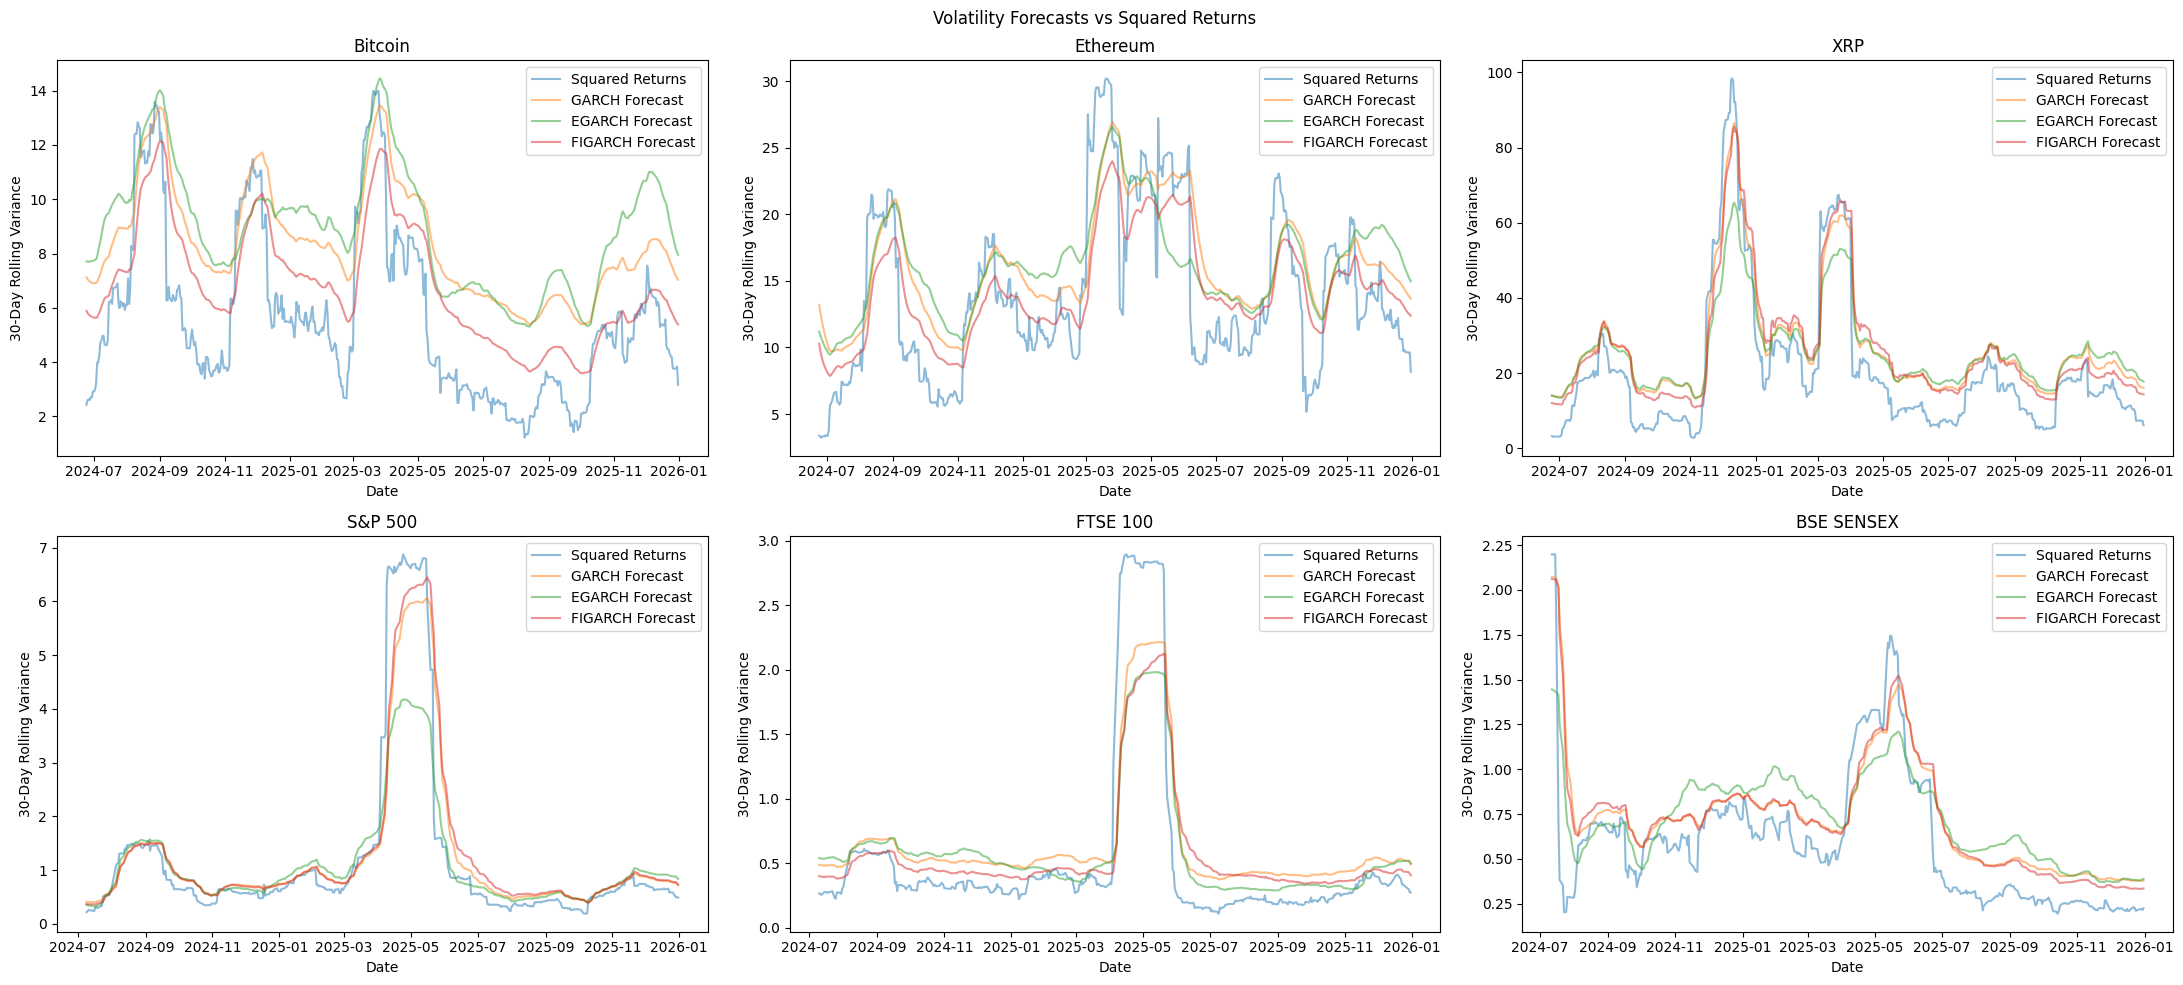

In [ ]:
#plot forecasts for all models against observed volatility

plt.figure(figsize=(22, 10))
plot_number = 1

for market in Markets:

  #2x3 grid
  plt.subplot(2, 3, plot_number)

  #plot observed volatility
  plt.plot(actual_variances[market].rolling(30).mean(),
           label = "Squared Returns",
           alpha = 0.5)

  #plot forecast for each model
  for model_name in models:

    plt.plot(predicted_variances[model_name][market].rolling(30).mean(),
             label = f"{model_name} Forecast",
             alpha = 0.5)

  plt.title(f"{market}")
  plt.ylabel("30-Day Rolling Variance")
  plt.xlabel("Date")
  plt.legend()

  plot_number += 1

plt.suptitle("Volatility Forecasts vs Squared Returns")

plt.tight_layout()

plt.savefig("Econ_Volatility_Forecast_Comparison.png",
            dpi = 300,
            bbox_inches = "tight")

plt.show()

In [ ]:
#calculate MAE and RMSE
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
econ_results = []

for market in Markets:
  results = {"Market": market}

  for model_name in models:

    actual = actual_variances[market]
    predicted = predicted_variances[model_name][market]

    mae = mean_absolute_error(actual, predicted)
    rmse =root_mean_squared_error(actual, predicted)

    results[f"{model_name} MAE"] = mae
    results[f"{model_name} RMSE"] = rmse

  econ_results.append(results)

econ_results_df = pd.DataFrame(econ_results).round(4)

#order columns
econ_results_df = econ_results_df[
    ["Market",
     "GARCH MAE", "EGARCH MAE", "FIGARCH MAE",
     "GARCH RMSE", "EGARCH RMSE", "FIGARCH RMSE"]
]

econ_results_df.to_csv("econ_results_table.csv", index=False)

# **3. ML modelling**

In [ ]:
#import packages
from xgboost import XGBRegressor
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
#data preperation
#split data into training, validation and test
#create hyperparameter tuning function to be used for all models
#create the target and split dates
ml_squared_returns = {}
train_dates = {}
validation_dates = {}
test_dates = {}

#use percentage returns to match arch models
for market in Markets:
  data = market_returns[market] * 100
  ml_squared_returns[market] = data ** 2
  #define split for training, validation and test
  train_split = int(len(data)*0.6)
  test_split = int(len(data)*0.8) #validation data is the 0.6-0.8
  train_dates[market] = data.index[:train_split]
  validation_dates[market] = data.index[train_split:test_split]
  test_dates[market] = data.index[test_split:]

#try look back windows same for both models
lookbacks = [5, 10, 20]

#hyperparameter tuning
def create_inputs(market, lookback):
  data = ml_squared_returns[market]
  X = [] #empty list to store input windows
  y = [] # "" to store answers
  dates = []

  #move through observations one at a time
  #start at observation 20 so all windows considered
  for i in range(max(lookbacks), len(data)):
    #take lookback observations and add to X
    X.append(data.iloc[i-lookback:i].to_numpy())

    #store date
    dates.append(data.index[i])

    #store the answer
    y.append(data.iloc[i])

  X = pd.DataFrame(X, index = dates) #table of inputs
  y = pd.Series(y, index = dates) #column of answers
  return X, y


1. XGBoost model

In [ ]:
#XGBoost model
#choose hyperparameters using validation data

xgb_validation_results = []

for market in Markets:
  print(f'XGBoost validation: {market}')
  for lookback in lookbacks:
    #use create_inputs function defined above
    X, y = create_inputs(market, lookback)
    #locate the rows where each date is in the training period
    X_train = X.loc[X.index.isin(train_dates[market])]
    y_train = y.loc[X_train.index]
    #locate the rows where each date is in the validation
    X_validation = X.loc[X.index.isin(validation_dates[market])]
    y_validation = y.loc[X_validation.index]

    for depth in [2,3]:
      for trees in [100,300]:
        model = XGBRegressor(max_depth=depth,
                             n_estimators=trees,
                             learning_rate=0.03,
                             objective = 'reg:squarederror',
                             random_state = 42,
                             n_jobs=2)
        model.fit(X_train, y_train)
        forecast = model.predict(X_validation)
        forecast = np.maximum(forecast, 0) #can't be negative
        rmse = root_mean_squared_error(y_validation, forecast)
        xgb_validation_results.append({
        "Market": market,
        "Lookback": lookback,
        "Depth": depth,
        "Trees": trees,
        "Validation RMSE": rmse })

xgb_validation_results_df = pd.DataFrame(xgb_validation_results)
xgb_validation_results_df

XGBoost validation: Bitcoin
XGBoost validation: Ethereum
XGBoost validation: XRP
XGBoost validation: S&P 500
XGBoost validation: FTSE 100
XGBoost validation: BSE SENSEX


,Market,Lookback,Depth,Trees,Validation RMSE
0,Bitcoin,5,2,100,100.153318
1,Bitcoin,5,2,300,114.769928
2,Bitcoin,5,3,100,100.117528
3,Bitcoin,5,3,300,119.737045
4,Bitcoin,10,2,100,96.991291
...,...,...,...,...,...
67,BSE SENSEX,10,3,300,0.762079
68,BSE SENSEX,20,2,100,0.915600
69,BSE SENSEX,20,2,300,0.794213
70,BSE SENSEX,20,3,100,0.871492


In [ ]:
#choose parameters with lowest rmse
XGBoost_predictions = {}
actual = {}
xgb_settings = []
for market in Markets:
  #select validation results for current market
  results = xgb_validation_results_df[
      xgb_validation_results_df["Market"] == market]
  #locate the row that gives the smallest RMSE
  best = results.loc[results["Validation RMSE"].idxmin()]
  xgb_settings.append(best.to_dict())

  #create inputs using chosen lookback (ensure integer)
  X,y = create_inputs(market, int(best['Lookback']))

  #train model on training and validation data (first 80%)
  #this keeps consistency with econometric models

  #combine training and validation periods (all dates before test period)
  #select every input row
  X_past = X.loc[X.index < test_dates[market][0]].copy() #copy
  #select every correspodning answer
  y_past = y.loc[X_past.index].copy()

  #select test inputs and their answers
  X_test = X.loc[test_dates[market]]
  y_test = y.loc[X_test.index] #added after each is forecasted

  forecasts = []

  #fit each test data (adding each input after it is forecasted)
  for i in range(len(X_test)):
    #use the best parameters identified in create_inputs
    model = XGBRegressor(n_estimators=int(best['Trees']),
                         max_depth=int(best['Depth']),
                         learning_rate=0.03,
                         objective='reg:squarederror',
                         random_state=42,
                         n_jobs=2)
    model.fit(X_past, y_past)
    #predict only one test observation
    forecast = model.predict(X_test.iloc[i:i+1])[0]
    #store prediction (repace with zero if prediction is 0)
    forecasts.append(max(float(forecast), 0))

    #add the actual observation after making forecast
    X_past = pd.concat([X_past, X_test.iloc[i:i+1]])
    y_past = pd.concat([y_past, y_test.iloc[i:i+1]])

    #print progress every 50 forecasts
    if (i + 1) % 50 == 0 or i == len(X_test) - 1:
      print(f'XGBoost {market}: {i + 1}/{len(X_test)} forecasts')

  XGBoost_predictions[market] = pd.Series(
     forecasts,
     index=test_dates[market]
  )
  actual[market] = y_test

pd.DataFrame(XGBoost_predictions).to_csv("XGBoost_predictions.csv")
xgb_validation_results_df.to_csv("xgb_validation_results.csv", index=False)


XGBoost Bitcoin: 50/585 forecasts
XGBoost Bitcoin: 100/585 forecasts
XGBoost Bitcoin: 150/585 forecasts
XGBoost Bitcoin: 200/585 forecasts
XGBoost Bitcoin: 250/585 forecasts
XGBoost Bitcoin: 300/585 forecasts
XGBoost Bitcoin: 350/585 forecasts
XGBoost Bitcoin: 400/585 forecasts
XGBoost Bitcoin: 450/585 forecasts
XGBoost Bitcoin: 500/585 forecasts
XGBoost Bitcoin: 550/585 forecasts
XGBoost Bitcoin: 585/585 forecasts
XGBoost Ethereum: 50/585 forecasts
XGBoost Ethereum: 100/585 forecasts
XGBoost Ethereum: 150/585 forecasts
XGBoost Ethereum: 200/585 forecasts
XGBoost Ethereum: 250/585 forecasts
XGBoost Ethereum: 300/585 forecasts
XGBoost Ethereum: 350/585 forecasts
XGBoost Ethereum: 400/585 forecasts
XGBoost Ethereum: 450/585 forecasts
XGBoost Ethereum: 500/585 forecasts
XGBoost Ethereum: 550/585 forecasts
XGBoost Ethereum: 585/585 forecasts
XGBoost XRP: 50/585 forecasts
XGBoost XRP: 100/585 forecasts
XGBoost XRP: 150/585 forecasts
XGBoost XRP: 200/585 forecasts
XGBoost XRP: 250/585 foreca

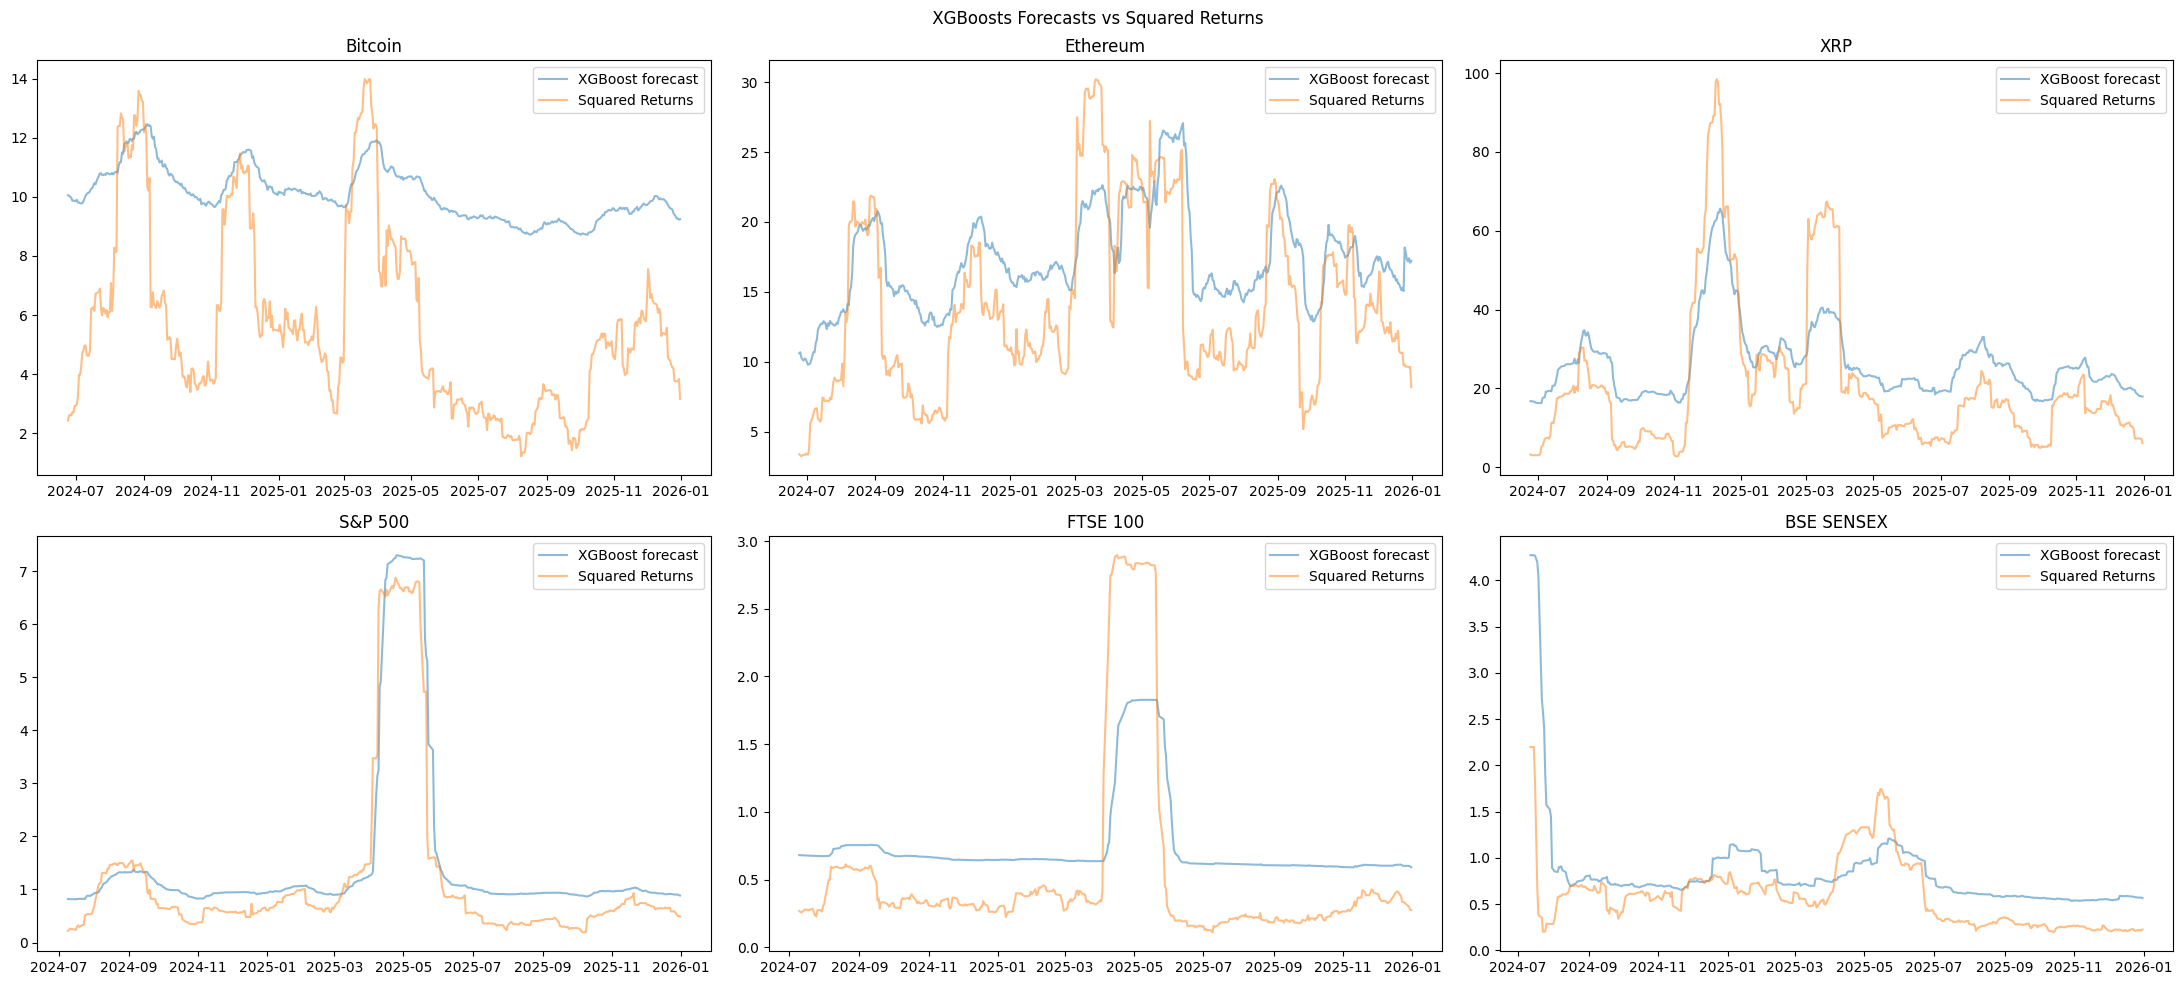

In [ ]:
#plot observed volatility against XGBoost predicted volatility

plt.figure(figsize=(22, 10))
plot_number = 1

for market in Markets:
  #2x3 grid
  plt.subplot(2, 3, plot_number)

  plt.plot(XGBoost_predictions[market].rolling(30).mean(),
            label = "XGBoost forecast",
            alpha = 0.5)
  plt.plot(actual[market].rolling(30).mean(),
            label = "Squared Returns",
            alpha = 0.5)

  plt.title(f"{market}")
  plt.legend()
  plot_number += 1
plt.suptitle(" XGBoosts Forecasts vs Squared Returns")
plt.tight_layout()
plt.savefig('XGBoost_model_plot.png',
              dpi=300,
              bbox_inches='tight')
plt.show()

2. LSTM model

In [ ]:
#LSTM model
from sklearn.preprocessing import StandardScaler
#scale the training data
lstm_scalers = {}
for market in Markets:
  #locate training data
  training_data = ml_squared_returns[market].loc[train_dates[market]]
  #use StandardScaler
  scaler = StandardScaler()
  #fit to training data only and reshape
  scaler.fit(training_data.to_numpy().reshape(-1, 1))
  #store each markets scaler
  lstm_scalers[market] = scaler
#define lstm model
def lstm_model(lookbacks, units):
  tf.keras.backend.clear_session()
  tf.keras.utils.set_random_seed(42)
  model = Sequential([
    Input(shape=(lookbacks, 1)),
    LSTM(units),
    Dense(1)
  ])
  model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                loss='mse')
  return model

#hyperrparameter testing with validation data
lstm_validation_results = []
#hyperparameters to test
lstm_lookbacks = [5, 20, 30, 60]
lstm_units = [16, 32, 64]
lookbacks = lstm_lookbacks
lstm_validation_results = []
for market in Markets:
  scaler = lstm_scalers[market]
  for lookback in lookbacks:
    X, y = create_inputs(market, lookback)
    #locate training data
    X_train = X.loc[X.index.isin(train_dates[market])]
    y_train = y.loc[X_train.index]

    #locate validation data
    X_validation = X.loc[X.index.isin(validation_dates[market])]
    y_validation = y.loc[X_validation.index]

    #scale training inputs
    X_train_scaled = scaler.transform(
        X_train.to_numpy().reshape(-1, 1)
        ).reshape(-1, lookback, 1)

    #scale training target
    y_train_scaled = scaler.transform(
        y_train.to_numpy().reshape(-1, 1))

    #scale validation
    X_validation_scaled = scaler.transform(
        X_validation.to_numpy().reshape(-1, 1)
    ).reshape(-1, lookback, 1)

    #scale validation target
    y_validation_scaled = scaler.transform(
        y_validation.to_numpy().reshape(-1, 1)
    )
    for units in lstm_units:
      model = lstm_model(lookback, units)

      #early-stopping
      early_stop = EarlyStopping(
          monitor = 'val_loss',
          patience = 10,
          restore_best_weights = True
      )
      from time import perf_counter
      start = perf_counter()

      #fit the model
      history = model.fit(
          X_train_scaled,
          y_train_scaled,
          validation_data = (X_validation_scaled, y_validation_scaled),
          epochs =100,
          batch_size=32,
          shuffle=False,
          callbacks=[early_stop],
          verbose=0
      )
      elapsed = perf_counter() - start
      print(f'{market}, lookback {lookback}, units {units}: '
            f'{elapsed / 60:.1f} minutes, '
            f'{len(history.history["loss"])} epochs')

      forecast_scaled = model.predict(X_validation_scaled,
                                      verbose=0)
      forecast = scaler.inverse_transform(forecast_scaled)
      forecast = np.maximum(forecast, 0) #volatility can't be negative
      #calculate validation error and best epoch
      rmse = root_mean_squared_error(y_validation, forecast)
      best_epoch = int(np.argmin(history.history['val_loss'])) + 1

      lstm_validation_results.append({
          "Market": market,
          "Lookback": lookback,
          "Units": units,
          "Epochs": best_epoch,
          "Validation RMSE": rmse,
          "Scaled Validation RMSE": rmse / scaler.scale_[0]
      })

lstm_validation_results_df = pd.DataFrame(lstm_validation_results)



In [ ]:
#choose hyperparameters with lowest validation RMSE
LSTM_predictions = {}
lstm_params = []
lstm_actual = {}

for market in Markets:

  #select validation results
  results = lstm_validation_results_df[
      lstm_validation_results_df["Market"] == market]
  #locate the row with lowest validation RMSE
  best = results.loc[
      results["Validation RMSE"].idxmin()
  ]

  #store best parameters
  lstm_params.append(best.to_dict())

  #extract parameters
  best_lookback = int(best["Lookback"])
  best_units = int(best["Units"])
  best_epochs = int(best["Epochs"])

  #create inputs using chosen lookback (ensure integer)
  X, y = create_inputs(market, best_lookback)

  #training and validation data (first 80%)
  X_past = X.loc[
      X.index < test_dates[market][0]
  ].copy()
  y_past = y.loc[X_past.index].copy()

  #test data
  X_test = X.loc[test_dates[market]]
  y_test = y.loc[X_test.index]

  #scale data with scaler fitted already
  scaler = lstm_scalers[market]

  #training and validation data
  X_past_scaled = scaler.transform(X_past.to_numpy().reshape(-1,1)
  ).reshape(-1, best_lookback, 1)
  y_past_scaled = scaler.transform(y_past.to_numpy().reshape(-1,1))

  #test data
  X_test_scaled = scaler.transform(X_test.to_numpy().reshape(-1,1)
  ).reshape(-1, best_lookback, 1)

  #create model with best parameters
  model = lstm_model(best_lookback, best_units)

  #train model on training and validation data
  model.fit(
      X_past_scaled,
      y_past_scaled,
      epochs = best_epochs,
      batch_size = 32,
      shuffle = False,
      verbose = 0
  )
  #forecast test data
  forecast_scaled = model.predict(
      X_test_scaled,
      verbose = 0
  )
  #convert forecasts back to original scale
  forecasts = scaler.inverse_transform(
      forecast_scaled
  )
  #squared returns can't be negative
  forecasts = np.maximum(forecasts, 0)

  #store forecasts with dates
  LSTM_predictions[market] = pd.Series(
      forecasts.reshape(-1),
      index = X_test.index
  )

  #store squared returns
  lstm_actual[market] = y_test

pd.DataFrame(LSTM_predictions).to_csv("LSTM_predictions.csv")
lstm_validation_results_df.to_csv("lstm_validation_results.csv", index=False)


3. GARCH-LSTM model

In [ ]:
#GARCH-LSTM model

#empty dictionaries

actual_variances = {}
ml_squared_returns = {}

#create GARCH forecast to input into LSTM
garch_input = {}
for market in Markets:
    #split into 0-20%, 20-60
    data = market_returns[market] * 100
    initial_split = int(len(data) * 0.2) #start after first 20%
    validation_split = int(len(data) * 0.6)
    test_split = int(len(data) * 0.8)
    initial = data.iloc[:initial_split]
    lstm_train = data.iloc[initial_split:validation_split]
    validation = data.iloc[validation_split:test_split]
    test = data.iloc[test_split:]
    #generate GARCH inputs for both LSTM training and testing
    forecast_data = pd.concat([lstm_train, validation, test])
    past = initial.copy()
    actual_variances[market] = test ** 2
    ml_squared_returns[market] = data ** 2
    #one-step-ahead forecasting
    forecasts = []

    for i in range(len(forecast_data)):
    #define garch model
      model = arch_model(past, vol = "GARCH", p=1, q=1)
      #fit model
      model_fit = model.fit(disp='off')
      #forecast one step ahead
      forecast = model_fit.forecast(horizon=1)
      #extract variance forecast
      predicted_variance = forecast.variance.iloc[-1, 0]
      forecasts.append(predicted_variance)
      past = pd.concat([past, forecast_data.iloc[i:i+1]])
    #store predicted variance with test dates
    garch_input[market] = pd.Series(
          forecasts,
          index=forecast_data.index
      )
  #create hybrid inputs
def create_hybrid_inputs(market, lookback):
  squared_returns = ml_squared_returns[market]
  garch_variance = garch_input[market]
  squared_returns = squared_returns.loc[garch_variance.index]

  X = [] #empty list to store input windows
  y = [] # "" to store answers
  dates = []

  #move through observations one at a time
  #start at observation 20 so all windows considered
  for i in range(max(lstm_lookbacks), len(squared_returns)):
    #take lookback observations and add to X
    #dates included in lookback window
    window_dates = squared_returns.index[i-lookback:i]
    #squared return input
    returns_window = squared_returns.loc[window_dates].to_numpy()
    #GARCH input
    garch_window = garch_variance.loc[window_dates].to_numpy()
    #combine squared returns and GARCH forecasts
    X.append(
        np.column_stack([
            returns_window,
            garch_window])
    )
    #store date
    dates.append(squared_returns.index[i])

    #store the actual squared return
    y.append(squared_returns.iloc[i])

  X = np.array(X) #array of inputs
  y = pd.Series(y, index = dates) #column of answers
  return X, y, dates
X, y, dates = create_hybrid_inputs(
    "Bitcoin",
    20
)




In [ ]:
#create model like lstm_model
def garch_lstm_model(lookbacks, units):
  tf.keras.utils.set_random_seed(42)
  tf.keras.backend.clear_session()
  model = Sequential([
    Input(shape=(lookbacks, 2)),
    LSTM(units),
    Dense(1)
  ])
  model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                loss='mse')
  return model

#scale GARCH training data
garch_scalers = {}
for market in Markets:
  #locate training data
  training_data = garch_input[market].loc[
      garch_input[market].index.isin(train_dates[market])
      ]
  #use StandardScaler
  scaler = StandardScaler()
  #fit to training data
  scaler.fit(training_data.to_numpy().reshape(-1, 1))
  #store each markets scaler
  garch_scalers[market] = scaler

#hyperparameter testing
garch_lstm_validation_results = []

for market in Markets:
  return_scaler = lstm_scalers[market]
  garch_scaler = garch_scalers[market]
  for lookback in lookbacks:
    X, y, dates = create_hybrid_inputs(market, lookback)

    dates = pd.Index(dates)

    #locate training data
    train_mask = dates.isin(train_dates[market])
    X_train = X[train_mask]
    y_train = y.loc[dates[train_mask]]

    #locate validation data
    validation_mask = dates.isin(
        validation_dates[market])

    X_validation = X[validation_mask]
    y_validation = y.loc[
        dates[validation_mask]]

    #copy inputs before scaling
    X_train_scaled = X_train.copy()
    X_validation_scaled = X_validation.copy()
    #scale squared return feature
    X_train_scaled[:, :, 0] = (
        return_scaler.transform(
            X_train[:, :, 0].reshape(-1, 1)
        ).reshape(-1, lookback)
    )

    X_validation_scaled[:, :, 0] = (
        return_scaler.transform(
            X_validation[:, :, 0].reshape(-1, 1)
        ).reshape(-1, lookback)
    )

    #scale GARCH feature
    X_train_scaled[:, :, 1] = (
        garch_scaler.transform(
            X_train[:, :, 1].reshape(-1, 1)
        ).reshape(-1, lookback)
    )

    X_validation_scaled[:, :, 1] = (
        garch_scaler.transform(
            X_validation[:, :, 1].reshape(-1, 1)
        ).reshape(-1, lookback)
    )

    #scale training target
    y_train_scaled = return_scaler.transform(
        y_train.to_numpy().reshape(-1, 1)
    )

    #scale validation target
    y_validation_scaled = return_scaler.transform(
        y_validation.to_numpy().reshape(-1, 1)
    )

    for units in lstm_units:
      model = garch_lstm_model(lookback, units)

      #early-stopping
      early_stop = EarlyStopping(
          monitor = 'val_loss',
          patience = 10,
          restore_best_weights = True
      )

      #fit the model
      history = model.fit(
          X_train_scaled,
          y_train_scaled,
          validation_data = (X_validation_scaled, y_validation_scaled),
          epochs =100,
          batch_size=32,
          shuffle=False,
          callbacks=[early_stop],
          verbose=0
      )
       #forecast validation data
      forecast_scaled = model.predict(
          X_validation_scaled,
          verbose=0)

      #convert back to original squared-return scale
      forecast = return_scaler.inverse_transform(
          forecast_scaled)

      #squared returns cannot be negative
      forecast = np.maximum(forecast, 0)
      #calculate validation error and best epoch
      rmse = root_mean_squared_error(y_validation, forecast.reshape(-1))
      best_epoch = int(np.argmin(history.history['val_loss'])) + 1

      garch_lstm_validation_results.append({
          "Market": market,
          "Lookback": lookback,
          "Units": units,
          "Epochs": best_epoch,
          "Validation RMSE": rmse,
      })

garch_lstm_validation_results_df = pd.DataFrame(garch_lstm_validation_results)
garch_lstm_validation_results_df

,Market,Lookback,Units,Epochs,Validation RMSE
0,Bitcoin,5,16,1,17.355462
1,Bitcoin,5,32,1,17.555363
2,Bitcoin,5,64,1,17.592292
3,Bitcoin,20,16,1,17.397730
4,Bitcoin,20,32,1,17.582249
...,...,...,...,...,...
67,BSE SENSEX,30,32,3,0.717583
68,BSE SENSEX,30,64,1,0.701963
69,BSE SENSEX,60,16,1,0.708205
70,BSE SENSEX,60,32,17,0.710845


In [ ]:
#choose hyperparameters with lowest validation RMSE
GARCH_LSTM_predictions = {}
garch_lstm_params = []
garch_lstm_actual = {}

for market in Markets:

  #select validation results
  results = garch_lstm_validation_results_df[
      garch_lstm_validation_results_df["Market"] == market]
  #locate the row with lowest validation RMSE
  best = results.loc[
      results["Validation RMSE"].idxmin()
  ]

  #store best parameters
  garch_lstm_params.append(best.to_dict())

  #extract parameters
  best_lookback = int(best["Lookback"])
  best_units = int(best["Units"])
  best_epochs = int(best["Epochs"])

  #create inputs using chosen lookback (ensure integer)
  X, y, dates = create_hybrid_inputs(market, best_lookback)
  dates = pd.Index(dates)
  #training and validation data (first 80%)
  past_mask = dates < test_dates[market][0]
  X_past = X[past_mask].copy()
  y_past = y.loc[dates[past_mask]].copy()

  #test data
  test_mask = dates.isin(test_dates[market])
  X_test = X[test_mask].copy()
  y_test = y.loc[dates[test_mask]].copy()

  #scale data with scaler fitted already
  return_scaler = lstm_scalers[market]
  garch_scaler = garch_scalers[market]

  #training and validation data
  X_past_scaled = X_past.copy()
  X_test_scaled = X_test.copy()

  #scale squared return feature
  X_past_scaled[:, :, 0] = (
      return_scaler.transform(
          X_past[:, :, 0].reshape(-1, 1)
      ).reshape(-1, best_lookback)
  )

  X_test_scaled[:, :, 0] = (
      return_scaler.transform(
          X_test[:, :, 0].reshape(-1, 1)
      ).reshape(-1, best_lookback)
  )

  #scale GARCH feature
  X_past_scaled[:, :, 1] = (
      garch_scaler.transform(
          X_past[:, :, 1].reshape(-1, 1)
      ).reshape(-1, best_lookback)
  )

  X_test_scaled[:, :, 1] = (
      garch_scaler.transform(
          X_test[:, :, 1].reshape(-1, 1)
      ).reshape(-1, best_lookback)
  )

  #scale training target
  y_past_scaled = return_scaler.transform(
      y_past.to_numpy().reshape(-1, 1)
  )


  #create model with best parameters
  model = garch_lstm_model(best_lookback, best_units)

  #train model on training and validation data
  model.fit(
      X_past_scaled,
      y_past_scaled,
      epochs = best_epochs,
      batch_size = 32,
      shuffle = False,
      verbose = 0
  )
  #forecast test data
  forecast_scaled = model.predict(
      X_test_scaled,
      verbose = 0
  )
  #convert forecasts back to original scale
  forecasts = return_scaler.inverse_transform(
      forecast_scaled
  )
  #squared returns can't be negative
  forecasts = np.maximum(forecasts, 0)

  #store forecasts with dates
  GARCH_LSTM_predictions[market] = pd.Series(
      forecasts.reshape(-1),
      index = dates[test_mask]
  )

  #store squared returns
  garch_lstm_actual[market] = y_test

pd.DataFrame(GARCH_LSTM_predictions).to_csv("GARCH_LSTM_predictions.csv")
garch_lstm_validation_results_df.to_csv("garch_lstm_validation_results.csv", index=False)


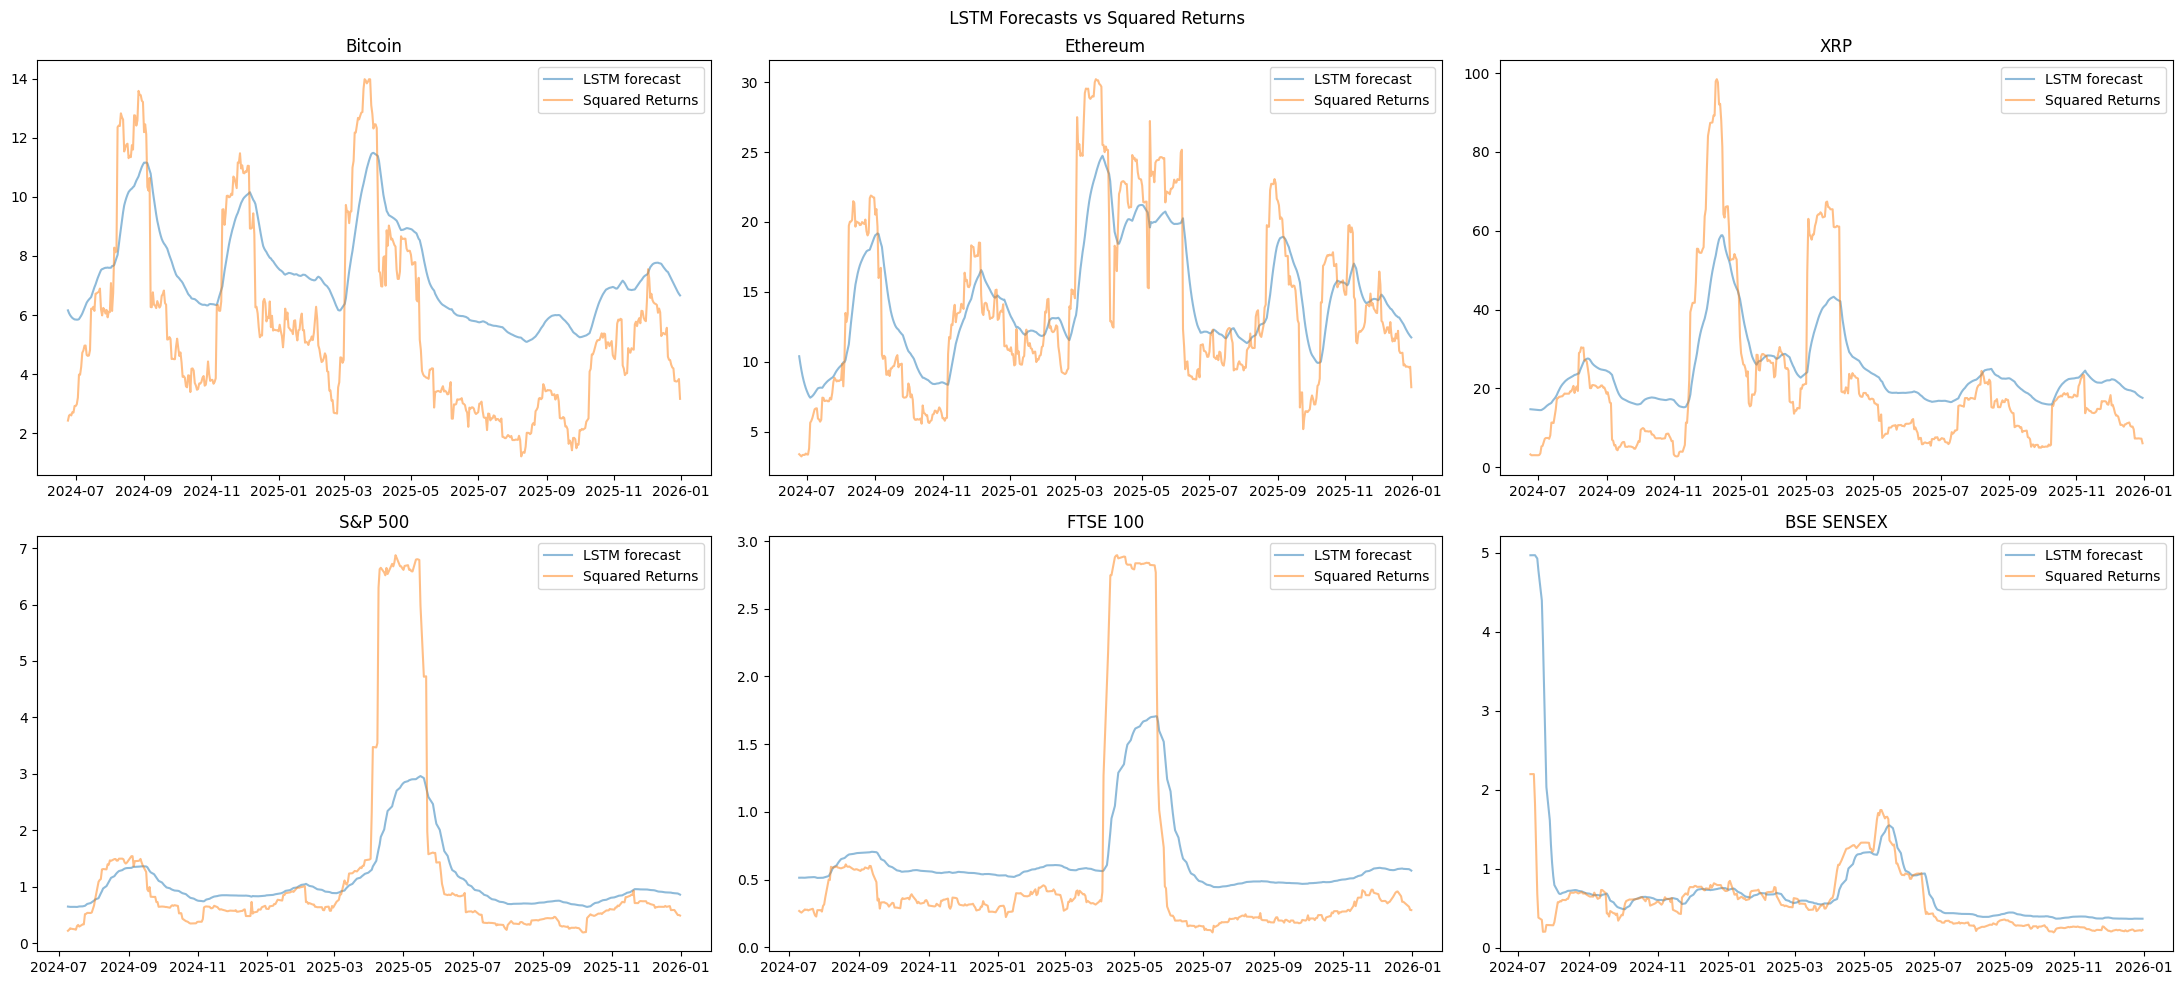

In [ ]:
#plot observed volatility against LSTM predicted volatility

plt.figure(figsize=(22, 10))
plot_number = 1

for market in Markets:
  #2x3 grid
  plt.subplot(2, 3, plot_number)

  plt.plot(LSTM_predictions[market].rolling(30).mean(),
            label = "LSTM forecast",
            alpha = 0.5)
  plt.plot(lstm_actual[market].rolling(30).mean(),
            label = "Squared Returns",
            alpha = 0.5)

  plt.title(f"{market}")
  plt.legend()
  plot_number += 1
plt.suptitle(" LSTM Forecasts vs Squared Returns")
plt.tight_layout()
plt.savefig('LSTM_model_plot.png',
              dpi=300,
              bbox_inches='tight')
plt.show()

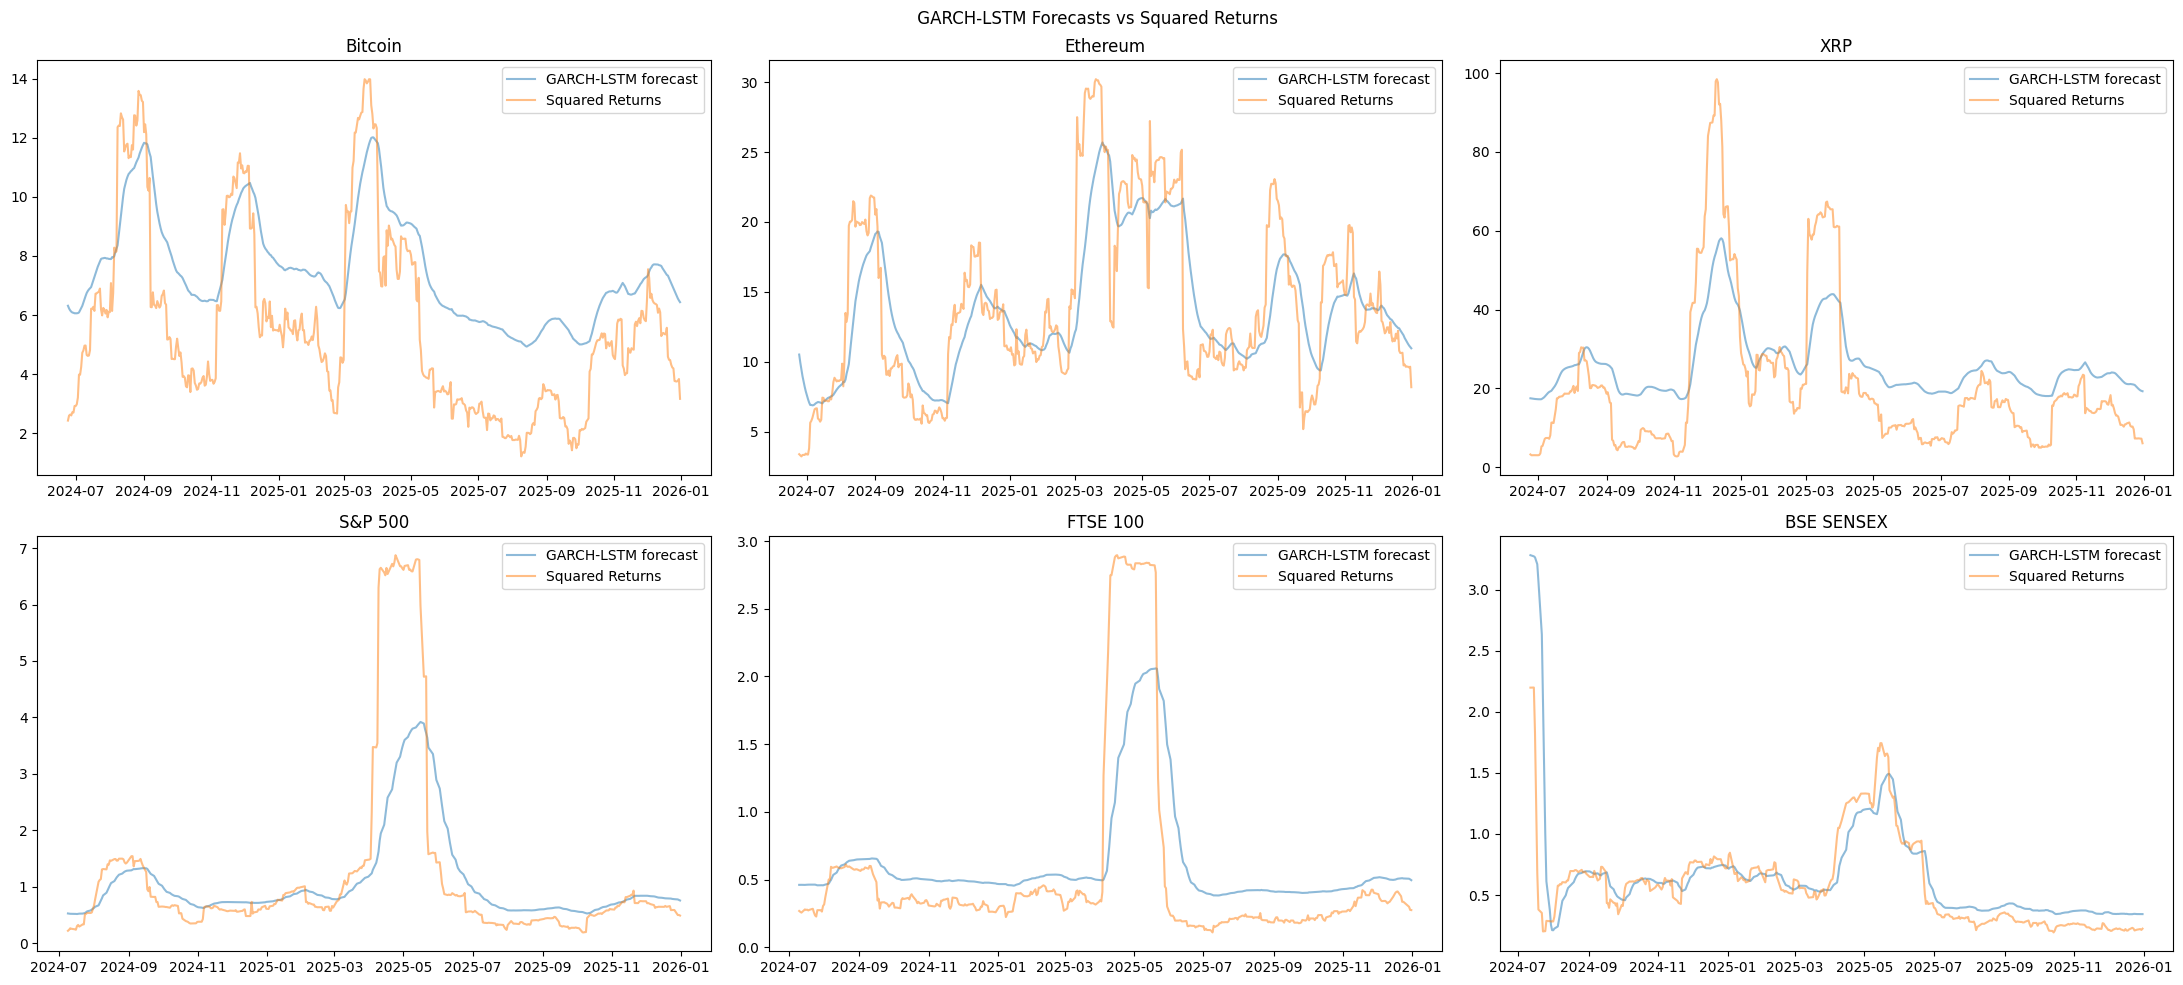

In [ ]:
#plot observed volatility against GARCH-LSTM predicted volatility

plt.figure(figsize=(22, 10))
plot_number = 1

for market in Markets:
  #2x3 grid
  plt.subplot(2, 3, plot_number)

  plt.plot(GARCH_LSTM_predictions[market].rolling(30).mean(),
            label = "GARCH-LSTM forecast",
            alpha = 0.5)
  plt.plot(garch_lstm_actual[market].rolling(30).mean(),
            label = "Squared Returns",
            alpha = 0.5)

  plt.title(f"{market}")
  plt.legend()
  plot_number += 1
plt.suptitle(" GARCH-LSTM Forecasts vs Squared Returns")
plt.tight_layout()
plt.savefig('GARCH_LSTM_model_plot.png',
              dpi=300,
              bbox_inches='tight')
plt.show()

4. Evaluation metrics for ML

In [ ]:
#calculate MAE and RMSE for ML models
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
ML_results = []

ML_models = ["XGBoost", "LSTM", "GARCH-LSTM"]

ML_predicted = {
    "XGBoost": XGBoost_predictions,
    "LSTM": LSTM_predictions,
    "GARCH-LSTM": GARCH_LSTM_predictions
}

for market in Markets:
  results = {"Market": market}

  for model_name in ML_models:

    actual = actual_variances[market]
    predicted = ML_predicted[model_name][market]

    mae = mean_absolute_error(actual, predicted)
    rmse =root_mean_squared_error(actual, predicted)

    results[f"{model_name} MAE"] = mae
    results[f"{model_name} RMSE"] = rmse

  ML_results.append(results)

ML_results_df = pd.DataFrame(ML_results).round(4)

#order columns
ML_results_df = ML_results_df[
    ["Market",
     "XGBoost MAE", "LSTM MAE", "GARCH-LSTM MAE",
     "XGBoost RMSE", "LSTM RMSE", "GARCH-LSTM RMSE"]
]

ML_results_df.to_csv("ML_results_table.csv", index=False)

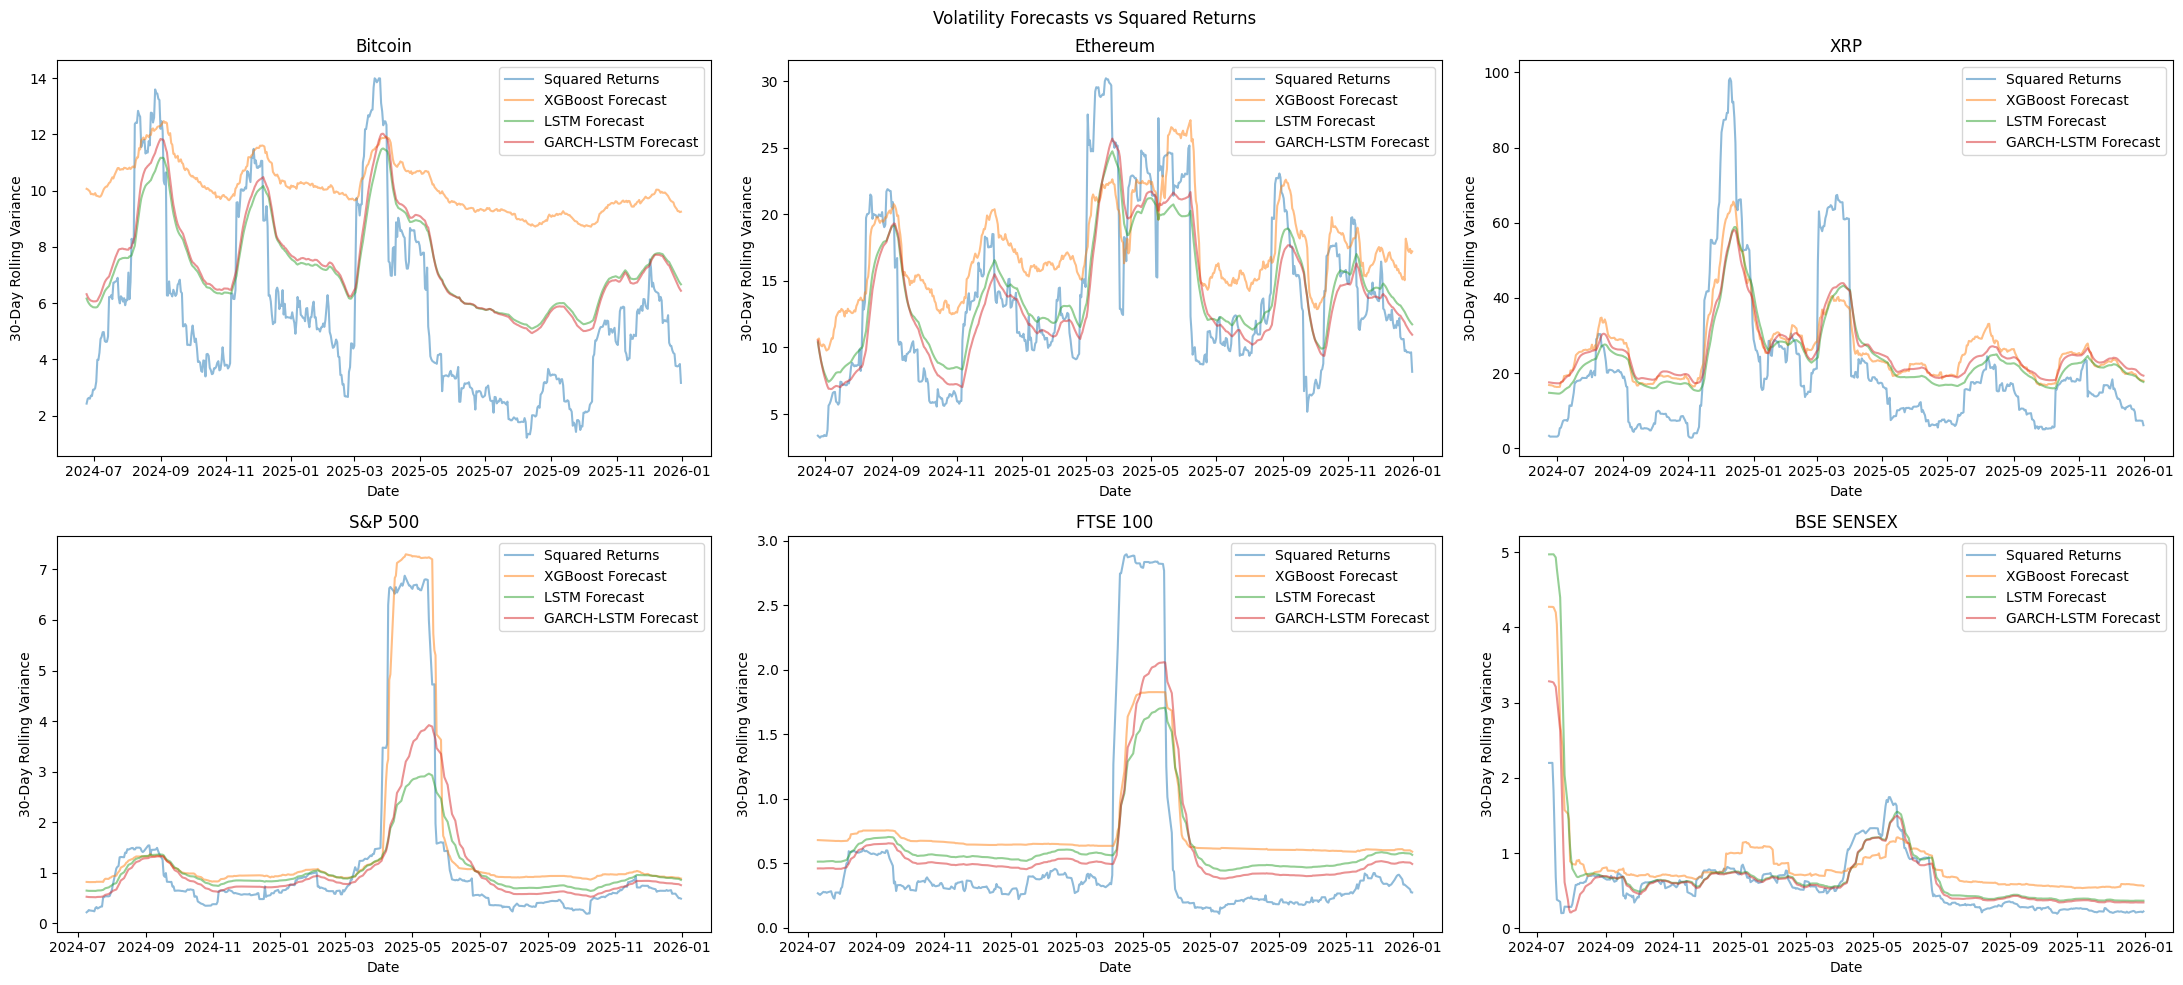

In [ ]:
#plot forecasts for all models against observed volatility

plt.figure(figsize=(22, 10))
plot_number = 1

for market in Markets:

  #2x3 grid
  plt.subplot(2, 3, plot_number)

  #plot observed volatility
  plt.plot(actual_variances[market].rolling(30).mean(),
           label = "Squared Returns",
           alpha = 0.5)

  #plot forecast for each model
  for model_name in ML_models:

    plt.plot(ML_predicted[model_name][market].rolling(30).mean(),
             label = f"{model_name} Forecast",
             alpha = 0.5)

  plt.title(f"{market}")
  plt.ylabel("30-Day Rolling Variance")
  plt.xlabel("Date")
  plt.legend()

  plot_number += 1

plt.suptitle("Volatility Forecasts vs Squared Returns")

plt.tight_layout()

plt.savefig("ML_Volatility_Forecast_Comparison.png",
            dpi = 300,
            bbox_inches = "tight")

plt.show()

5. Diebold-Mariano Test

In [ ]:
#diebold-mariano statistical test
#download package
!pip install dieboldmariano
from dieboldmariano import dm_test

In [ ]:

#test the best-performing ML model with the best-performing econometric model
#for each market
#based on RMSE

#put all model predictions together
all_predictions = {**predicted_variances, **ML_predicted}

#define function
def DM_test(model1, model2, market):
  #combine actual variances with predicted of model 1 and model 2 into one table
  data = pd.concat([
      actual_variances[market],
      all_predictions[model1][market],
      all_predictions[model2][market]
  ], axis=1)
  #perform diebold-mariano test
  statistic, p_value = dm_test(
      *data.to_numpy().T, #converts to numerical array
                         #transposes to give three rows: actual, model1, model2
                         # * passes rows as seperate arguments
      h=1)
  return{"DM statistic": statistic,
         "p-value": p_value}

DM_results = pd.DataFrame({
  "Bitcoin": DM_test("LSTM", "FIGARCH", "Bitcoin"),
  "Ethereum": DM_test("LSTM", "FIGARCH", "Ethereum"),
  "XRP": DM_test("LSTM", "EGARCH", "XRP"),
  "S&P 500": DM_test("LSTM", "EGARCH", "S&P 500"),
  "FTSE 100": DM_test("GARCH-LSTM", "FIGARCH", "FTSE 100"),
  "BSE SENSEX": DM_test("GARCH-LSTM", "FIGARCH", "BSE SENSEX")
}).T.round(4)

DM_results.to_csv("DM_results_table.csv", index_label = "Market")
